In [517]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#mpl.rcParams['font.family'] = 'Calibri'

import seaborn as sb
from statannot import add_stat_annotation
from scipy.stats import mannwhitneyu

import matplotlib.patches as mpatches
from scipy.stats import wilcoxon, ttest_ind
from scipy.stats import pearsonr

from scipy import stats
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects

from IPython.display import display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.expand_frame_repr', True)
import warnings
warnings.filterwarnings('ignore')

path = '/home/ripper8/projects/working_data/GRNv3knockouts/analysis'
experiments = ['reg10m2', 'reg2m2']
exp_labels = ['R10','R2']


ok


In [518]:
traits = ['disp_y', 'distance', 'extremities_prop', 'symmetry', 'proportion', 
          'coverage', 'extensiveness_prop', 'branching_prop','modules_count','hinge_prop']

traits_labels = ['fitness', 'growth', 'limbs', 'symmetry', 'proportion', 
              'coverage', 'limbs length', 'branching','size','joints']

df_traits = {}
df_categ_traits = {}

for trait in traits:
    print('>>>>>',trait)
    df_traits[trait] = pd.read_csv(f'{path}/knockouts/data/effects_{trait}.csv')
    df_traits[trait]['epistasis_percent'] = df_traits[trait]['positive'] + df_traits[trait]['negative']
    df_traits[trait]['avg_negative']  = df_traits[trait]['avg_negative'] * -1

    df_categ_traits[trait] = pd.read_csv(f'{path}/knockouts/data/effectscateg_{trait}.csv')

   
   

>>>>> disp_y
>>>>> distance
>>>>> extremities_prop
>>>>> symmetry
>>>>> proportion
>>>>> coverage
>>>>> extensiveness_prop
>>>>> branching_prop
>>>>> modules_count
>>>>> hinge_prop
ok


In [519]:

keys = ['experiment_name', 'run', 'gen', 'individual_id']

df_complexity = pd.read_csv(f'{path}/complexity/complexity.csv').drop(columns=['geno_size'])
df_complexity_net = pd.read_csv(f'{path}/complexity/complexity_net.csv')
df_complexity_all = pd.merge(df_complexity, df_complexity_net, on=keys, how='inner')

df_complexity_all['interactions_density'] = df_complexity_all['complexity_net'] / df_complexity_all['n_genes']


ok


>>>>> disp_y
>> 0


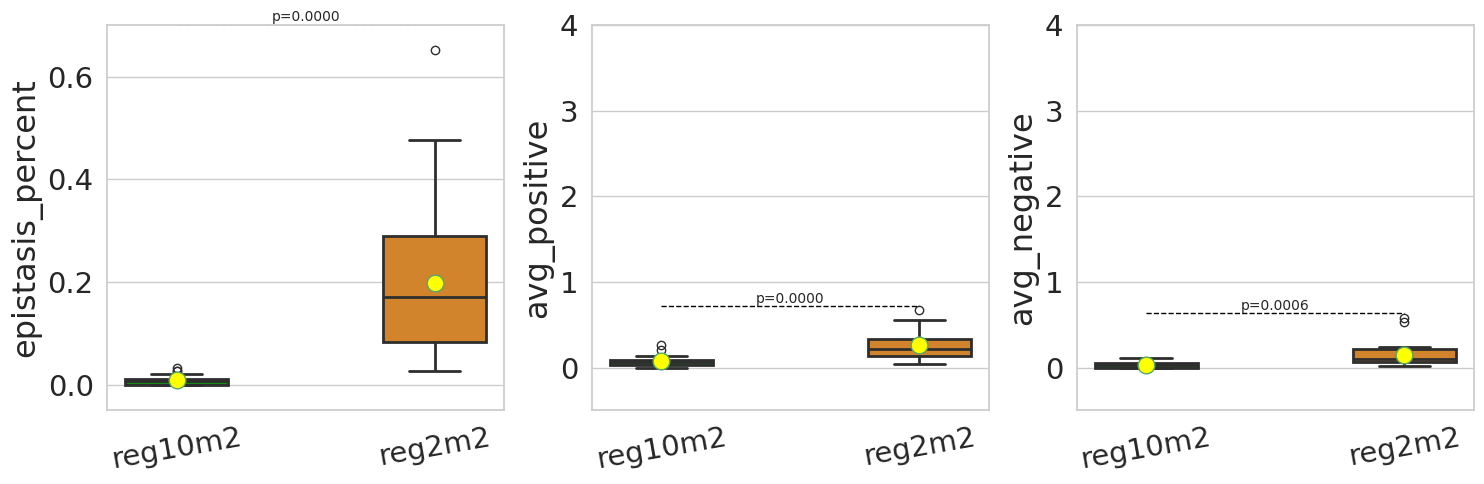

>> 100


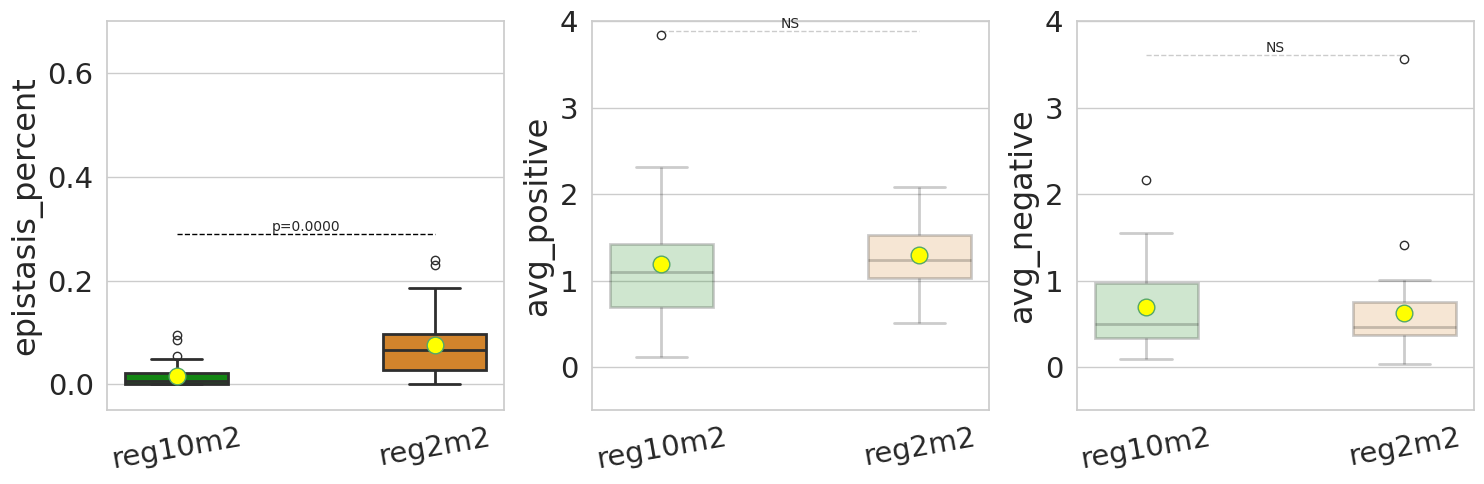

>>>>> distance
>> 0


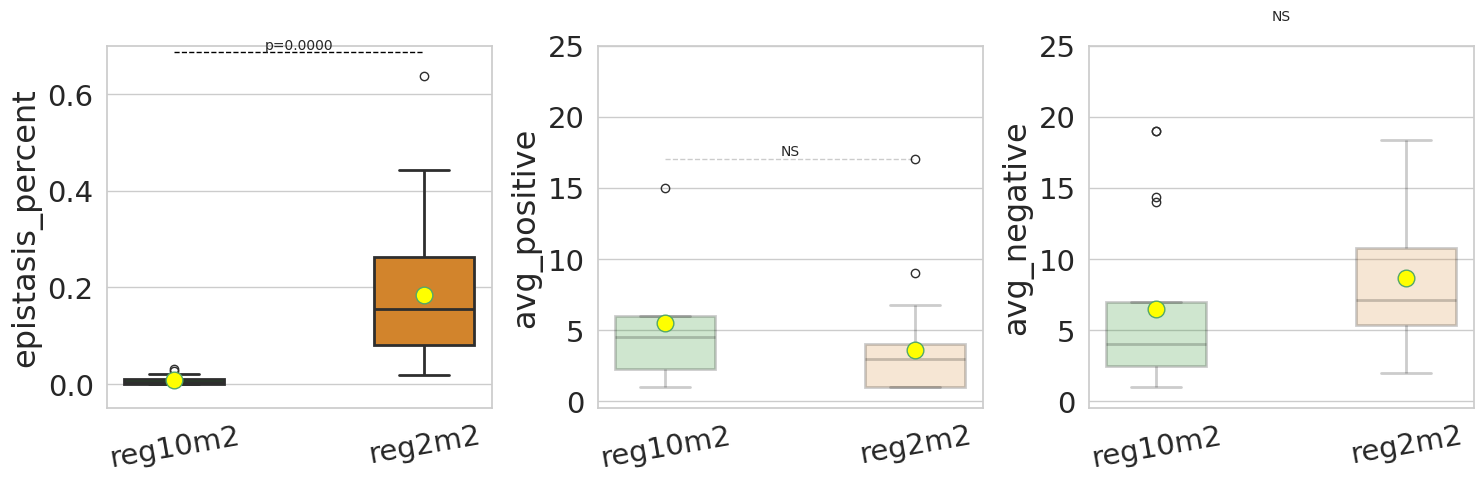

>> 100


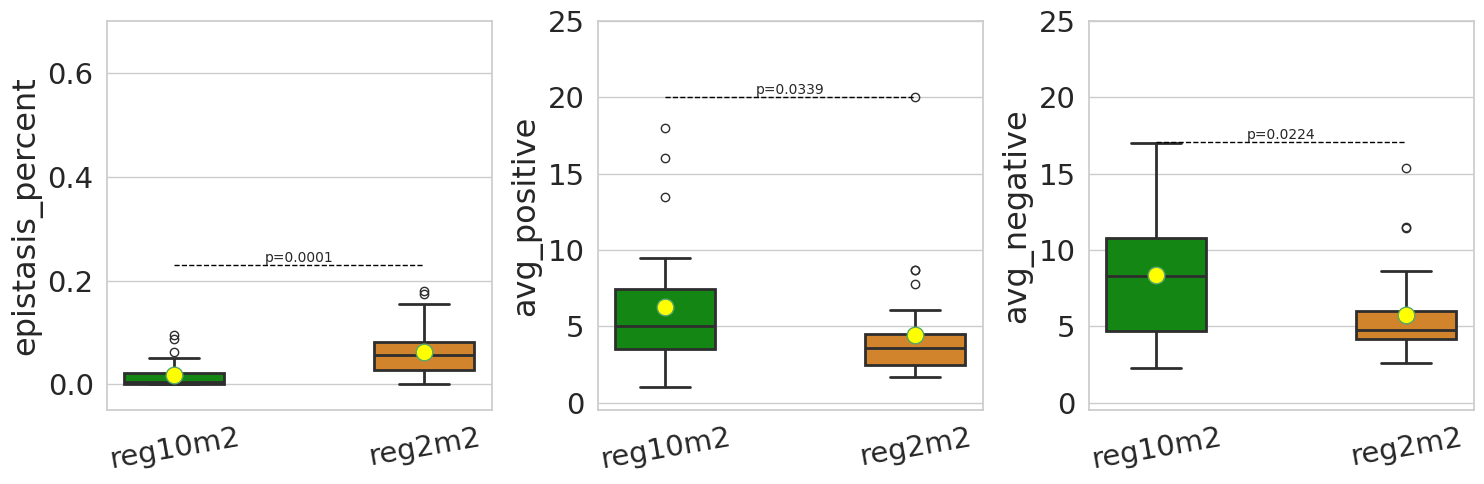

>>>>> extremities_prop
>> 0


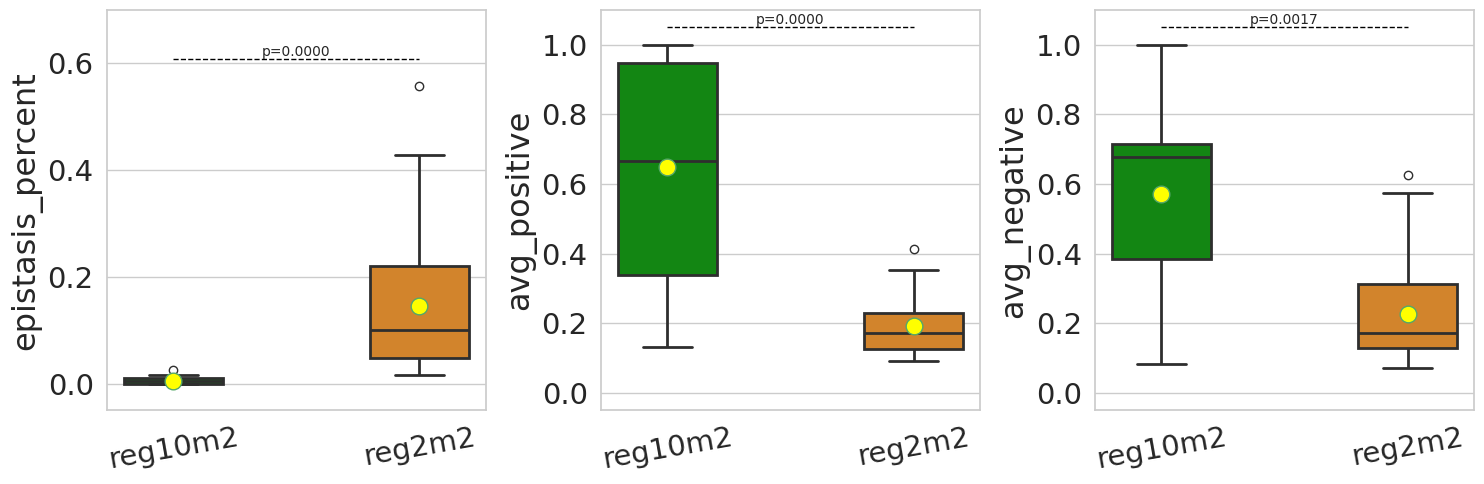

>> 100


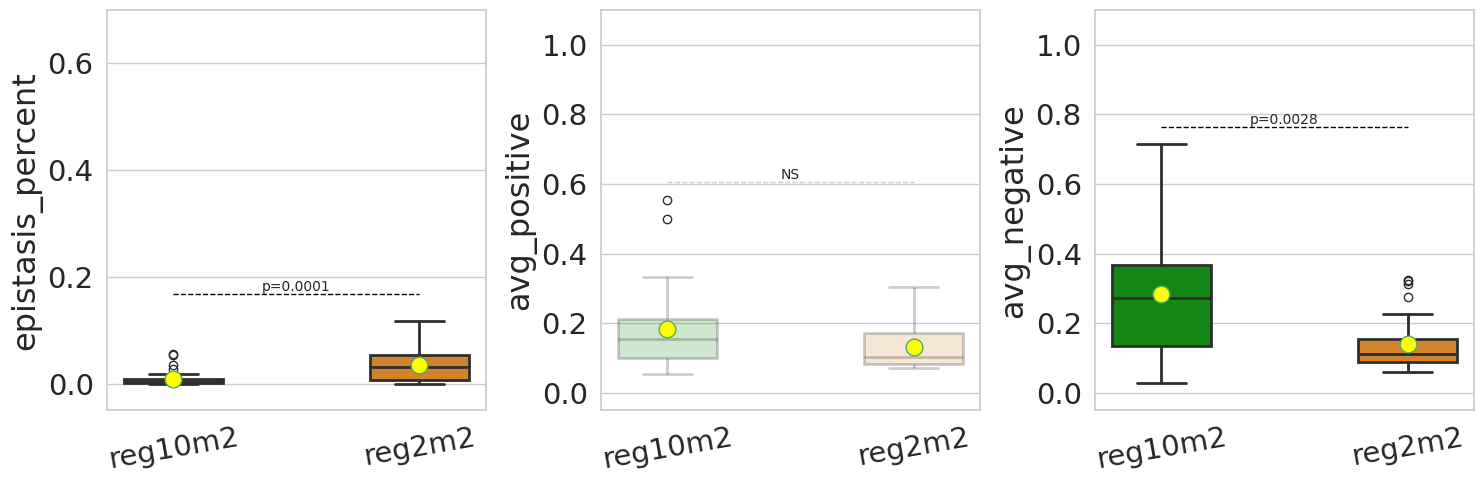

>>>>> symmetry
>> 0


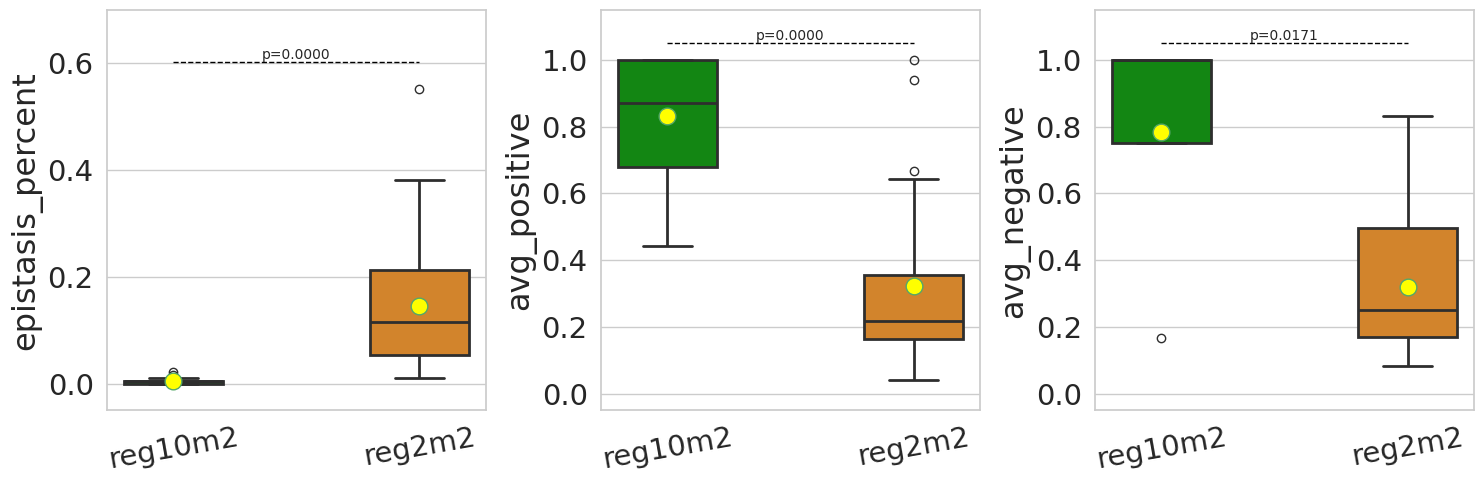

>> 100


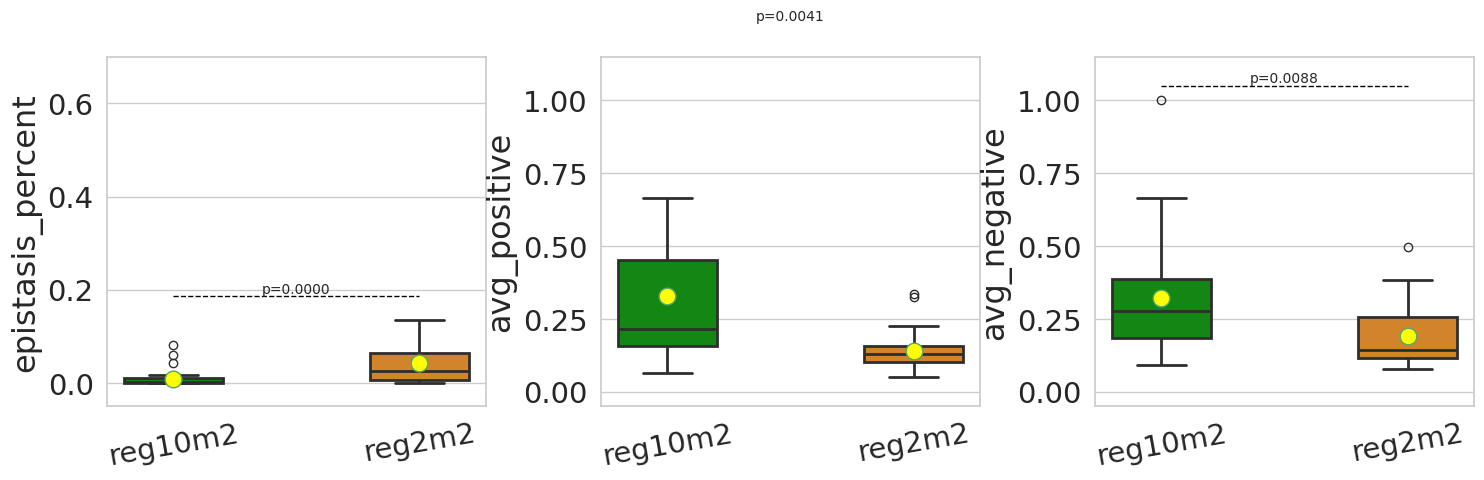

>>>>> proportion
>> 0


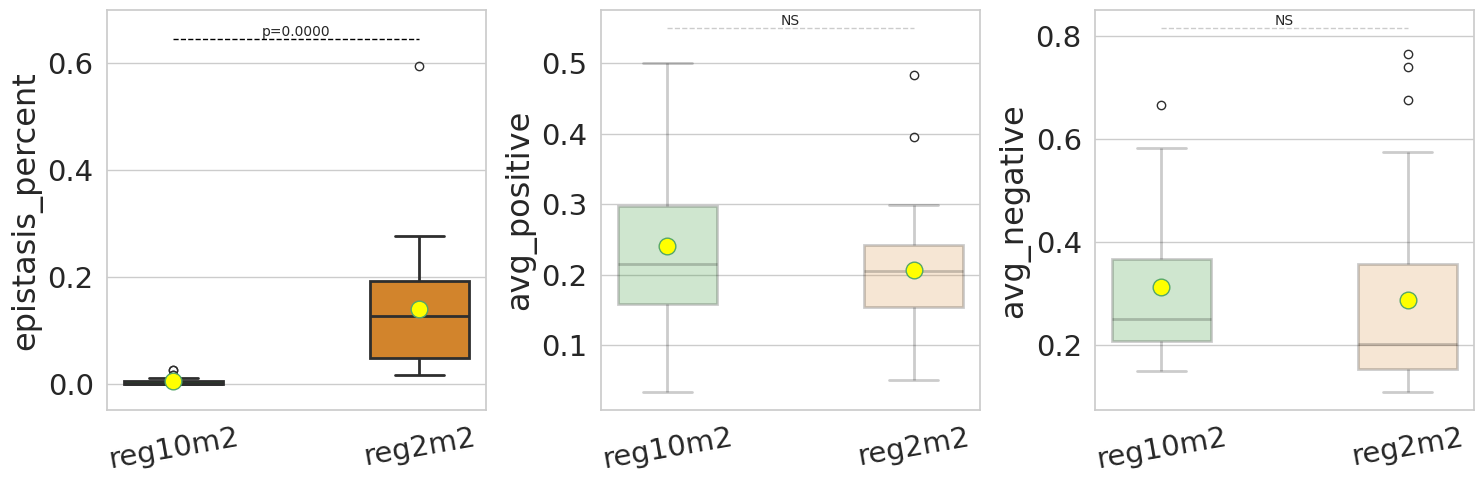

>> 100


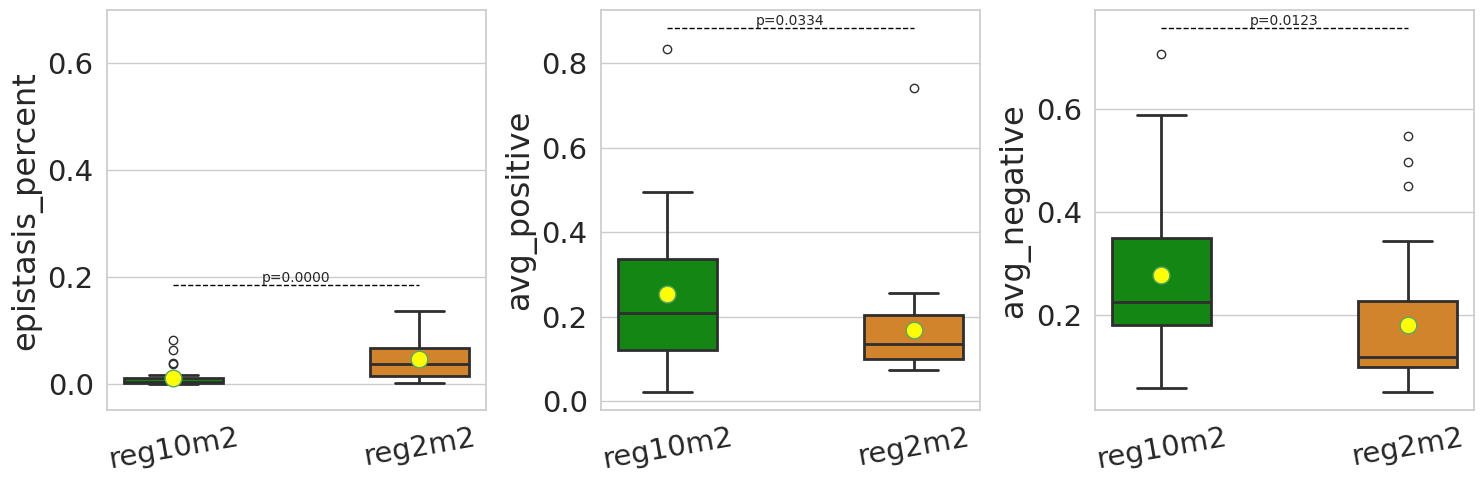

>>>>> coverage
>> 0


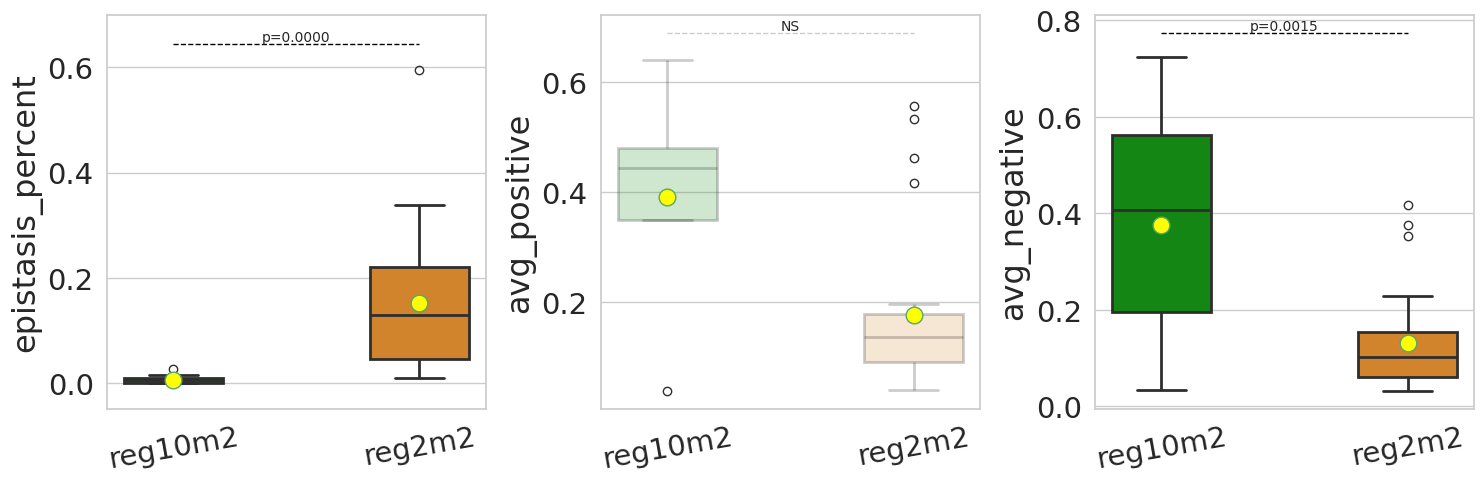

>> 100


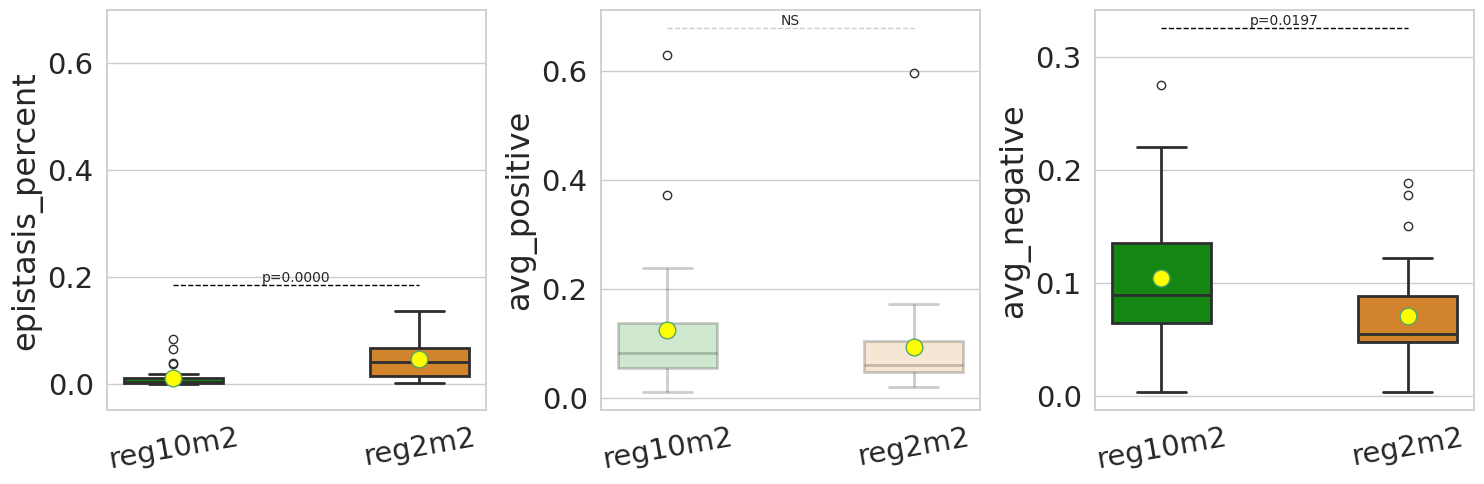

>>>>> extensiveness_prop
>> 0


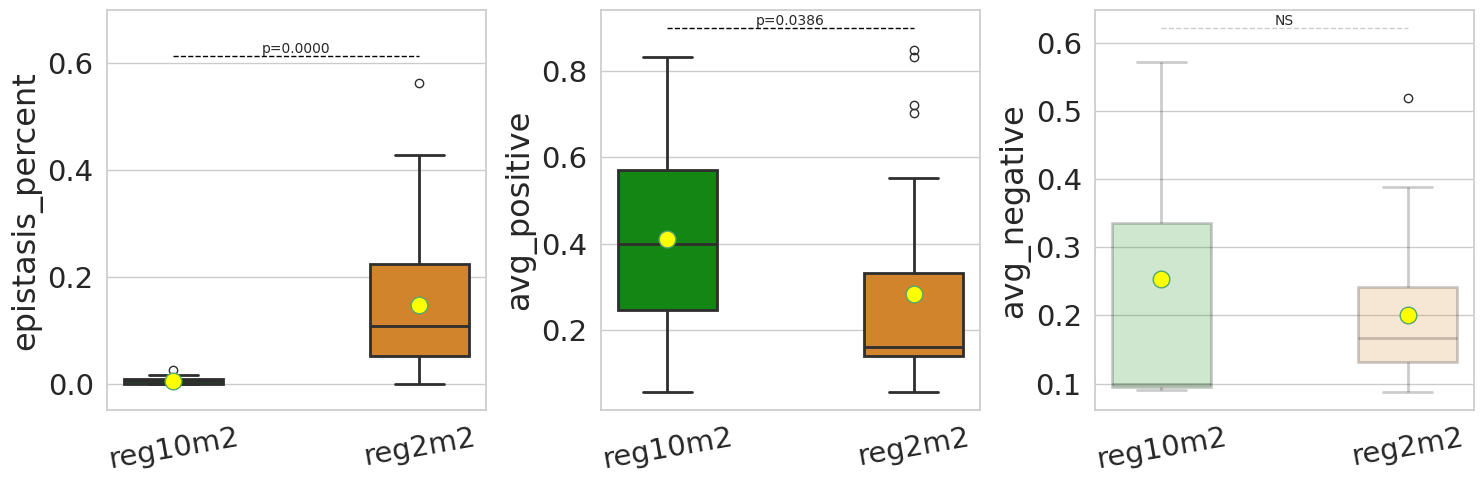

>> 100


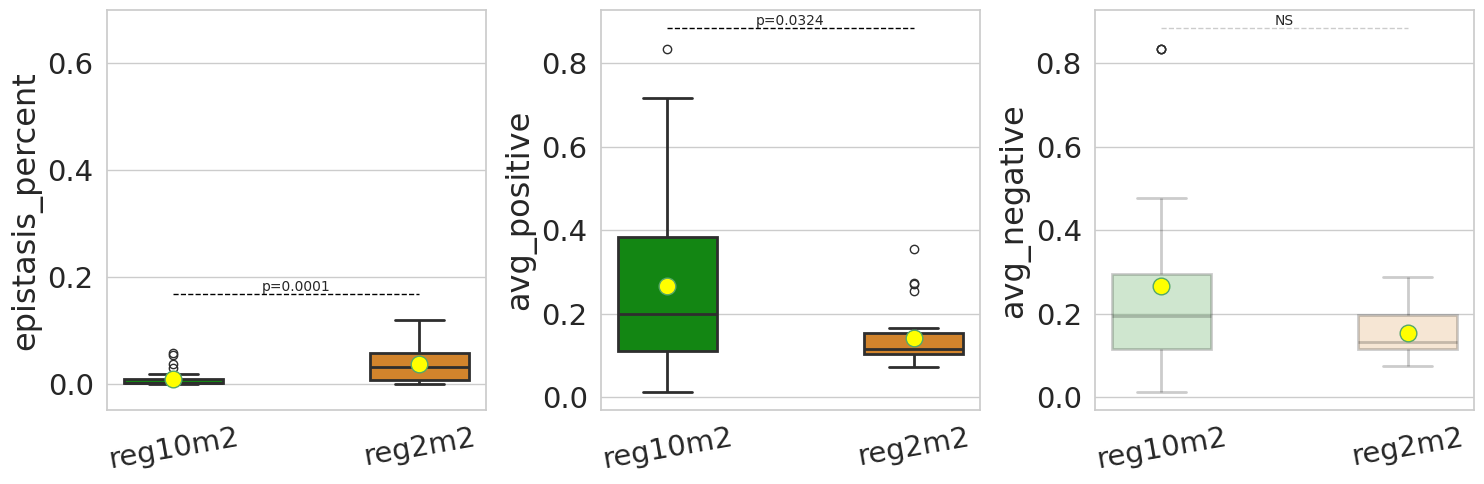

>>>>> branching_prop
>> 0


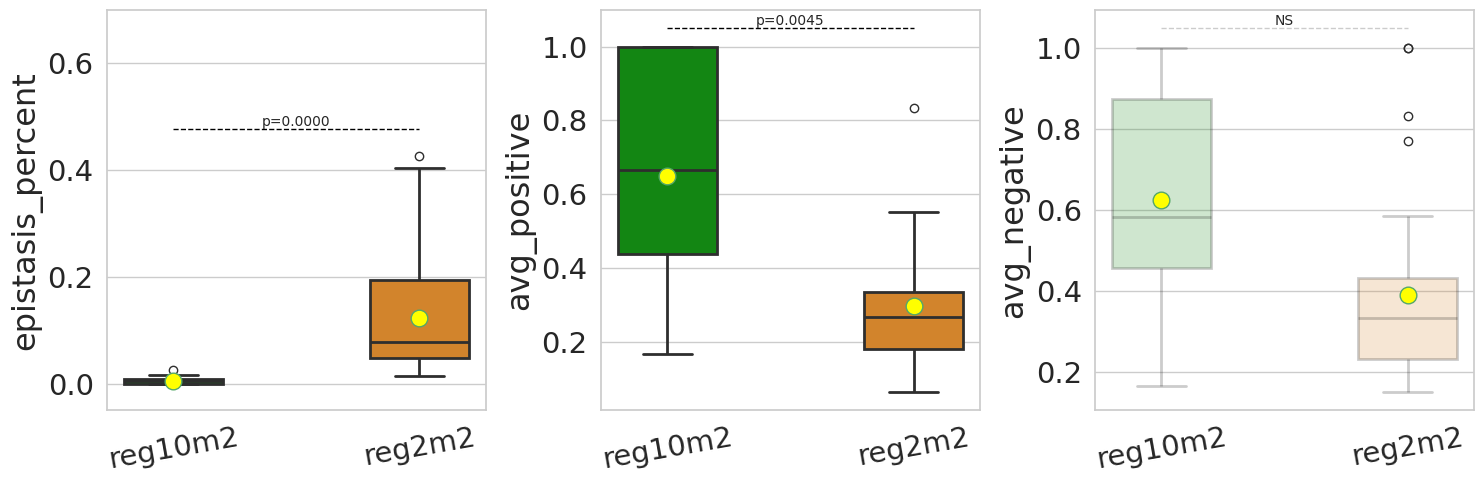

>> 100


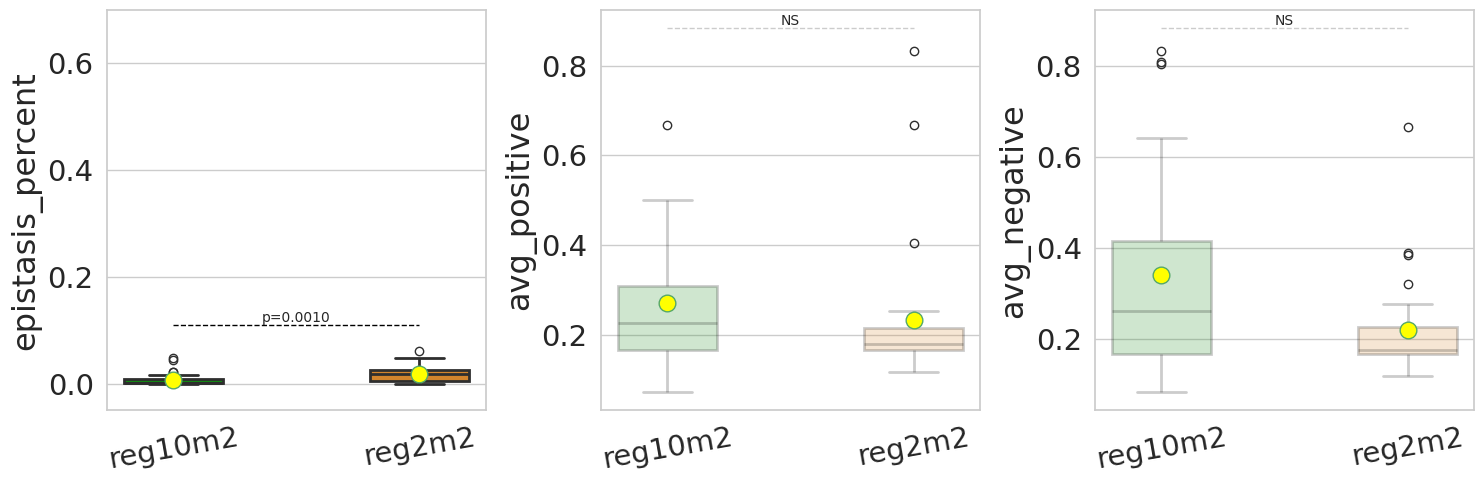

>>>>> modules_count
>> 0


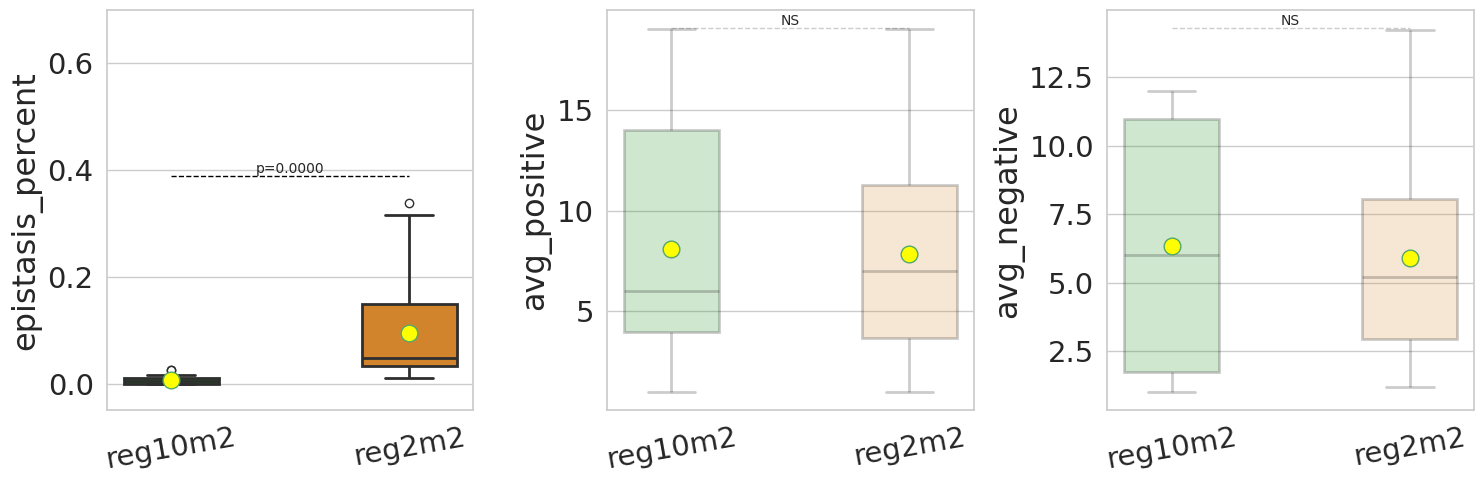

>> 100


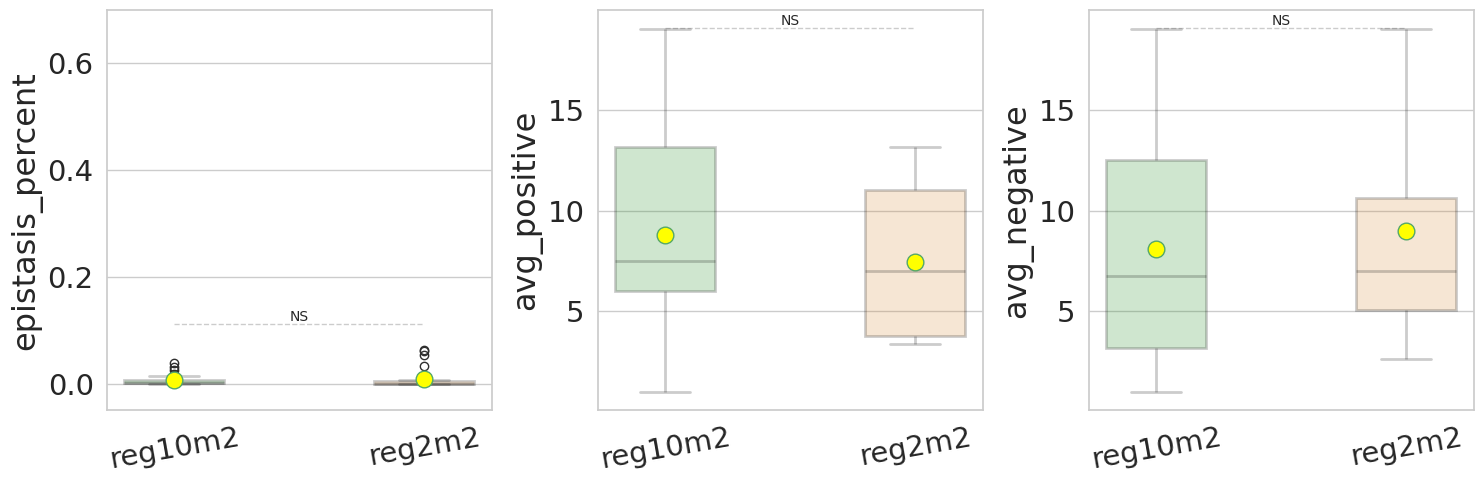

>>>>> hinge_prop
>> 0


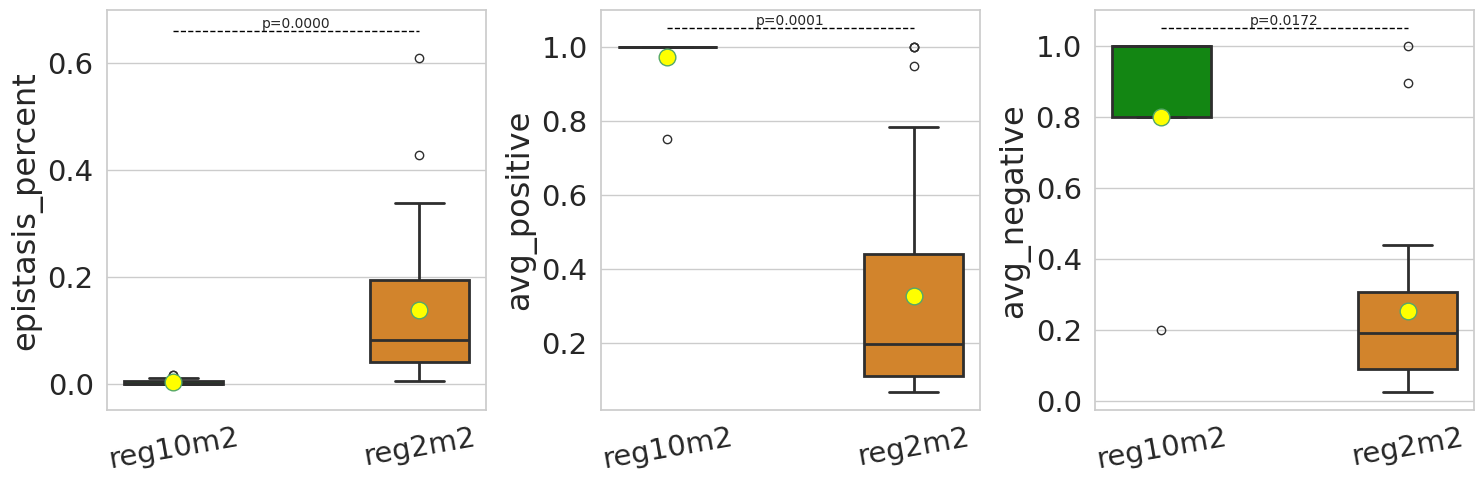

>> 100


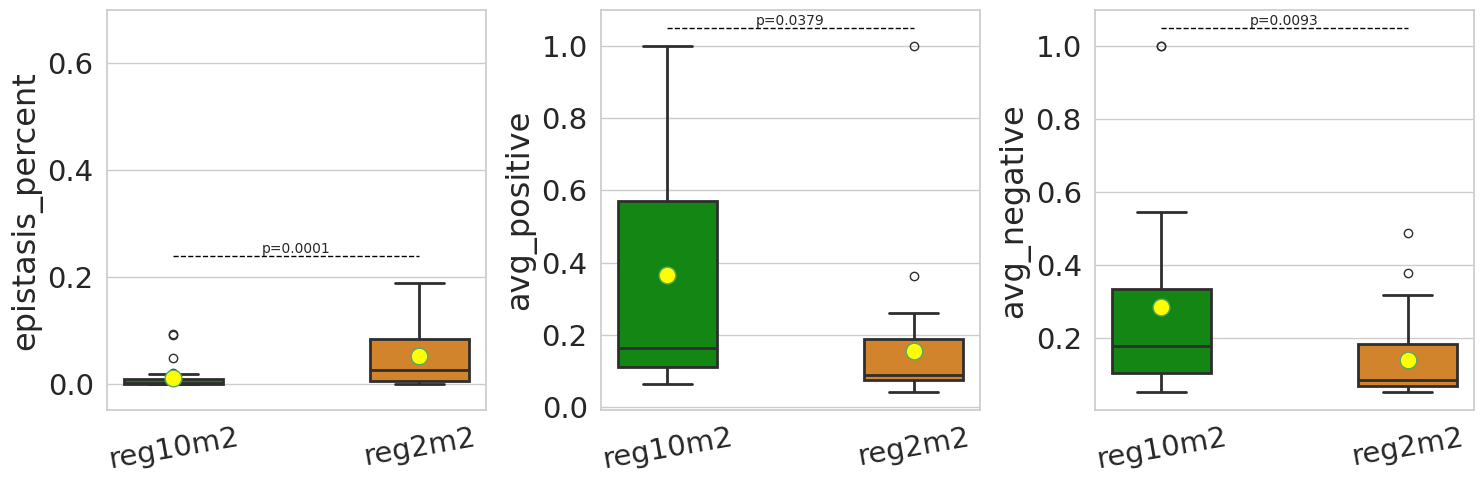

ok


In [520]:
### EPISTASIS CHANGES r10/r2: raw data ###

metrics = ['epistasis_percent',  'avg_positive',  'avg_negative']
metric_labels = ['epistasis %','strength +', 'strength $-$']
#epistasis strenght (+)
clrs = ['#009900',
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_traits[trait].copy(deep=True)
    
    for gen in [0, 100]:
        print('>>',gen)
        df_trait_exp = df_trait[df_trait['gen'] == gen]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
        sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
        sb.set_style("whitegrid")
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['experiment_name'] == 'reg10m2'][f'{metric}']
            end_gen = filtered_clean[filtered_clean['experiment_name'] == 'reg2m2'][f'{metric}']
     
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
           # print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='experiment_name', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)

            y_max = filtered_clean[f'{metric}'].max() + 0.05  #
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
            
            if metric in ['epistasis_percent']:
                ax.set_ylim(-0.05, 0.7)

            if metric == 'avg_positive' or metric == 'avg_negative':
                if trait in avg_pos_scale.keys():
                    ax.set_ylim(avg_pos_scale[trait][0], avg_pos_scale[trait][1])
      
            ax.tick_params(axis='x', labelrotation=10)
            
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')
       
        plt.tight_layout()
        plt.show()







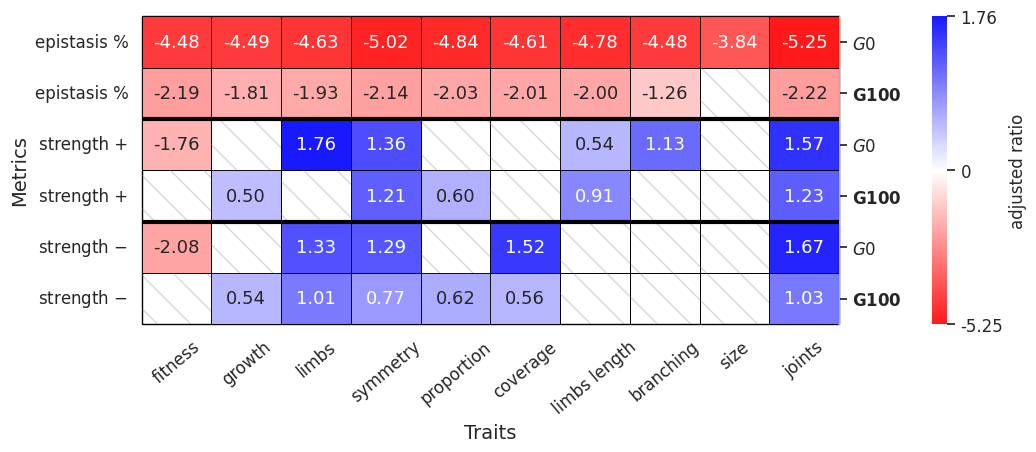

In [521]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.patches as patches

# Define traits and metrics
generations = [0, 100]

# Store ratio values for each metric, trait, and generation
heatmap_data = np.zeros((len(metrics) * len(generations), len(traits)))
heatmap_p = np.zeros((len(metrics) * len(generations), len(traits)))
annot_data = np.empty((len(metrics) * len(generations), len(traits)), dtype=object)

row_labels = []
gen_labels = []

for i, metric in enumerate(metrics):
    for gen_idx, gen in enumerate(generations):
        row_index = i * len(generations) + gen_idx
        row_labels.append(f"{metric}")
        if gen == 100:
            gen_labels.append(rf'$\mathbf{{G{gen}}}$')
        else:
            gen_labels.append(rf'$\mathit{{G{gen}}}$')
            
        for j, trait in enumerate(traits):
            df_trait = df_traits[trait].copy(deep=True)
            df_trait_exp = df_trait[df_trait['gen'] == gen]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            exp1 = filtered_clean[filtered_clean['experiment_name'] == 'reg2m2'][metric]
            exp2 = filtered_clean[filtered_clean['experiment_name'] == 'reg10m2'][metric]

            # Calculate averages and ratio
            avg_exp1 = exp1.mean()
            avg_exp2 = exp2.mean()
          #  perc = ((avg_exp2 / avg_exp1)-1) * 100
            transf_ratio = round(np.log2(avg_exp2 / avg_exp1),2)

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(exp1, exp2, alternative='two-sided')
            
            # Store in heatmap data
            heatmap_data[row_index, j] = transf_ratio
            heatmap_p[row_index, j] = p_value
          #  annot_data[row_index, j] = f"{transf_ratio:.0f}%"
            annot_data[row_index, j] = f"{transf_ratio:.02f}"

# Ensure finite values
heatmap_data = np.nan_to_num(heatmap_data, nan=0, posinf=np.nanmax(heatmap_data[np.isfinite(heatmap_data)]), neginf=np.nanmin(heatmap_data[np.isfinite(heatmap_data)]))

# Determine dynamic min and max values for normalization
vmin = np.min(heatmap_data)
vmax = np.max(heatmap_data)

# Create a colormap transitioning from red (negative values) to white (zero) to green (positive values)
cmap = LinearSegmentedColormap.from_list(
    "red_white_blue", ["red", "#ffffff", "blue"]
)

# Normalize the colormap with zero as the midpoint
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Create mask for non-significant values
mask_pvalue = heatmap_p > 0.05

fig, ax = plt.subplots(figsize=(12, 4))

# Plot the consolidated heatmap
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 13},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_pvalue, norm=norm,
   # cbar_kws={'label': r'Percentage difference ', 'pad': 0.1}
    cbar_kws={'label': r'adjusted ratio', 'pad': 0.1}
)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask_pvalue[i, j]:
            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0, edgecolor='grey',
                facecolor='none', hatch='\\' , alpha=0.3
            )
            ax.add_patch(rect)

# Remove grid lines
ax.set_xticks(ax.get_xticks(), minor=True)
ax.grid(False)

# Set x tick labels
ax.set_xticklabels(traits_labels, rotation=40, fontsize=12)

# Adjust y-axis labels
ax.set_yticklabels(np.repeat(metric_labels, 2), rotation=0, ha='right', fontsize=12)
ax2 = ax.secondary_yaxis('right')
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(gen_labels, rotation=0, ha='left', fontsize=12)

# Adjust color bar tick and label sizes
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.label.set_size(12)

# Ensure thick separating lines every two rows
for y in range(2, heatmap_data.shape[0], 2):
    ax.axhline(y=y, color='black', linewidth=3)

# Ensure bottom margin border is present
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1)

# 
#Set the ticks and labels for the colorbar
#colorbar_ticks = [-97,0,238]
colorbar_ticks = [vmin, 0 , vmax]
cbar.set_ticks(colorbar_ticks)
cbar.set_ticklabels([f"{tick}" for tick in colorbar_ticks])
#cbar.set_ticklabels([f"int({tick})%" for tick in colorbar_ticks])

plt.xlabel("Traits",fontsize=14)
plt.ylabel("Metrics",fontsize=14)

# Save figure
fig.savefig(f'{path}/knockouts/epistasis_change_R10R2.png', dpi=300, bbox_inches='tight')


>>>>> disp_y
>> reg10m2


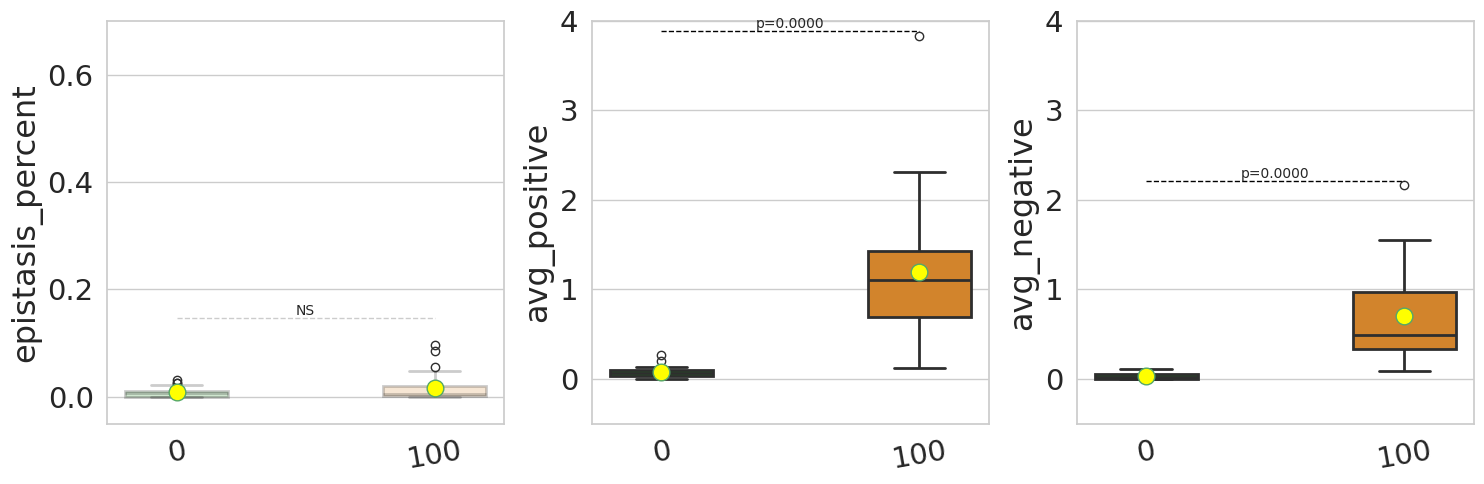

>> reg2m2


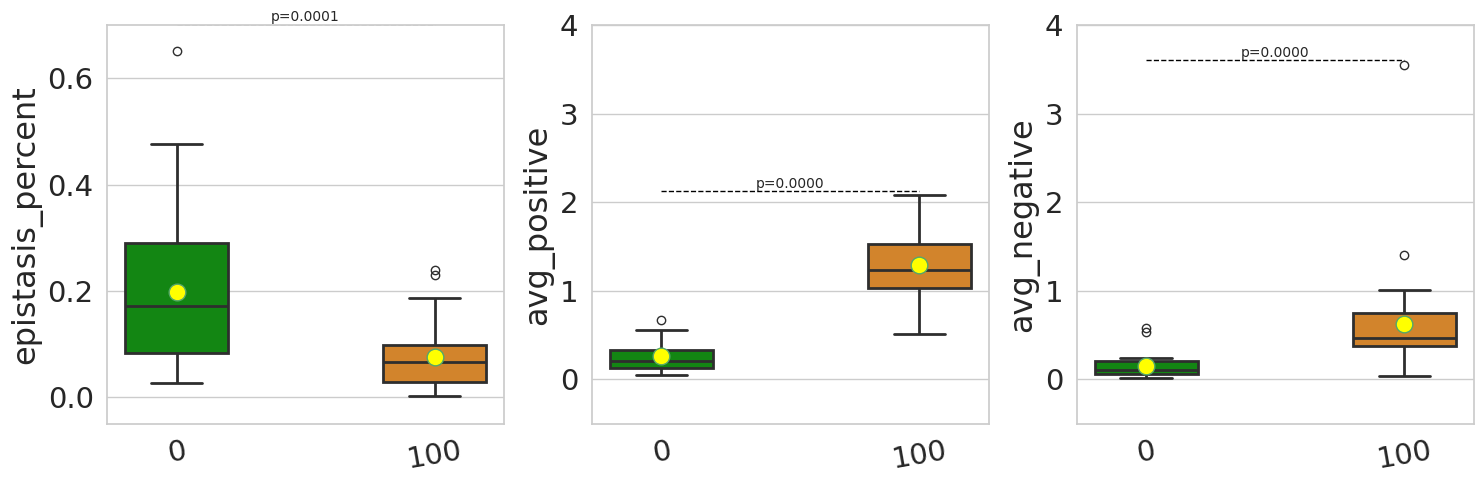

>>>>> distance
>> reg10m2


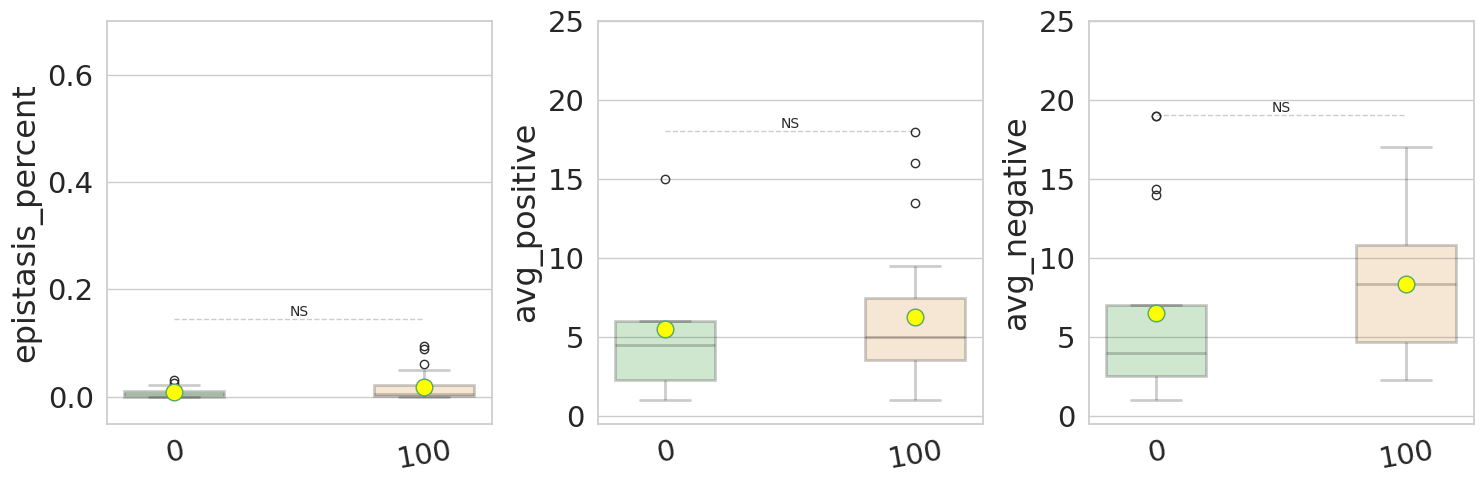

>> reg2m2


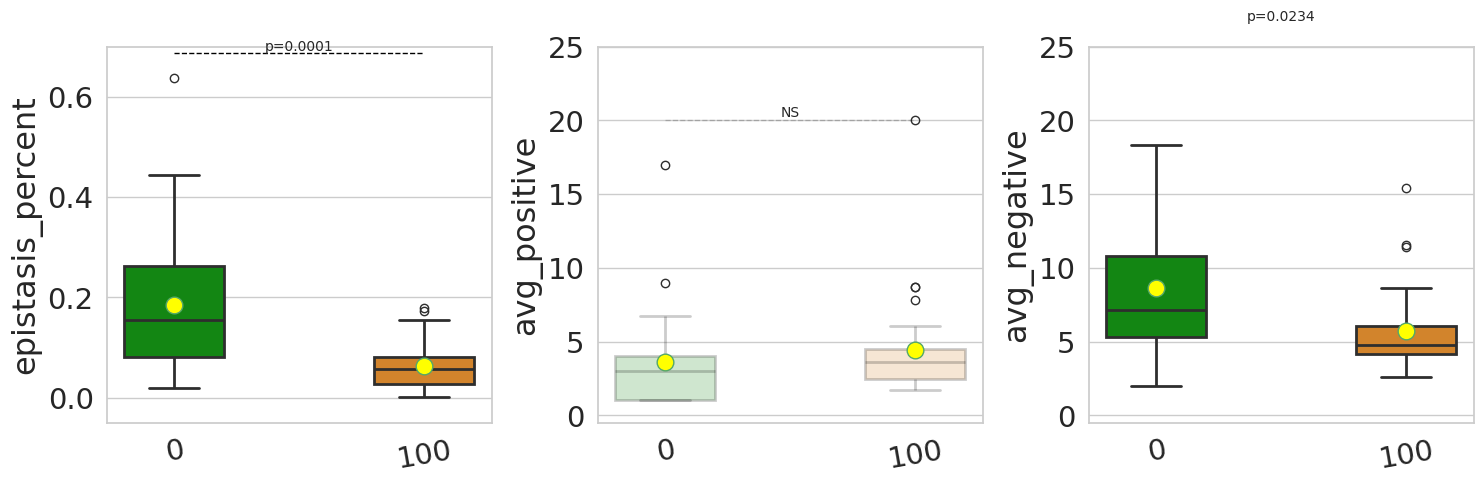

>>>>> extremities_prop
>> reg10m2


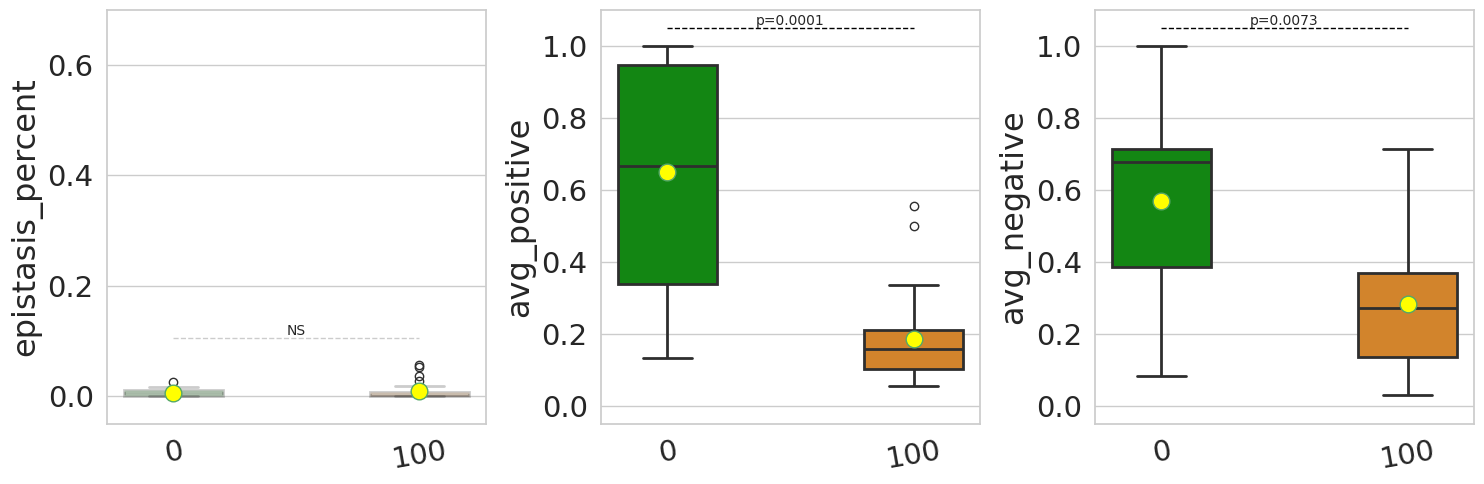

>> reg2m2


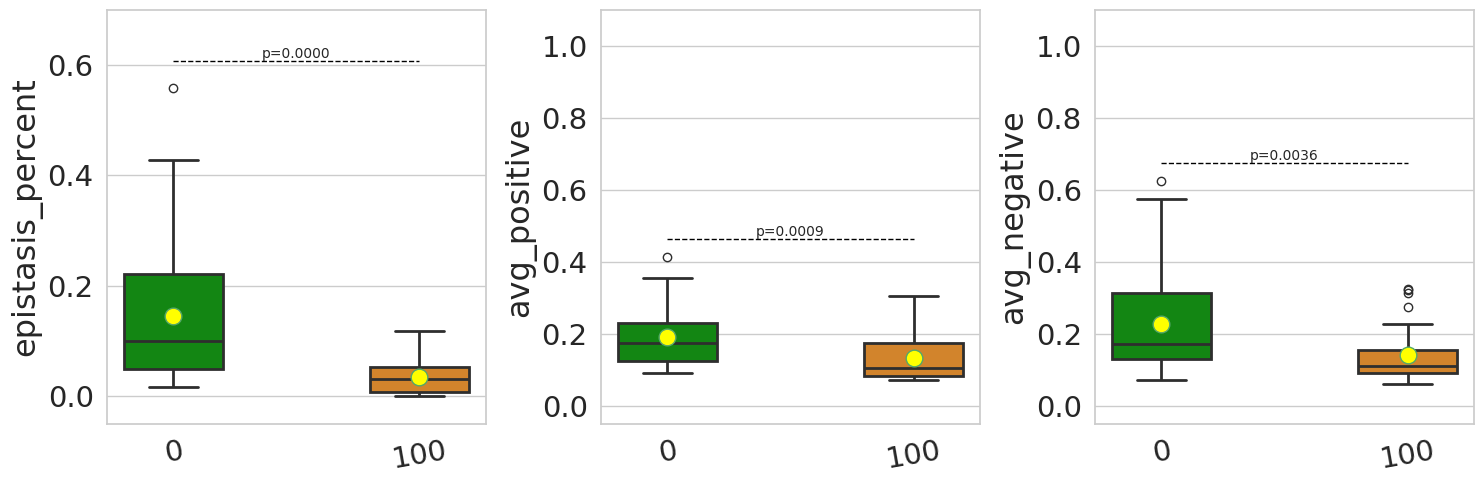

>>>>> symmetry
>> reg10m2


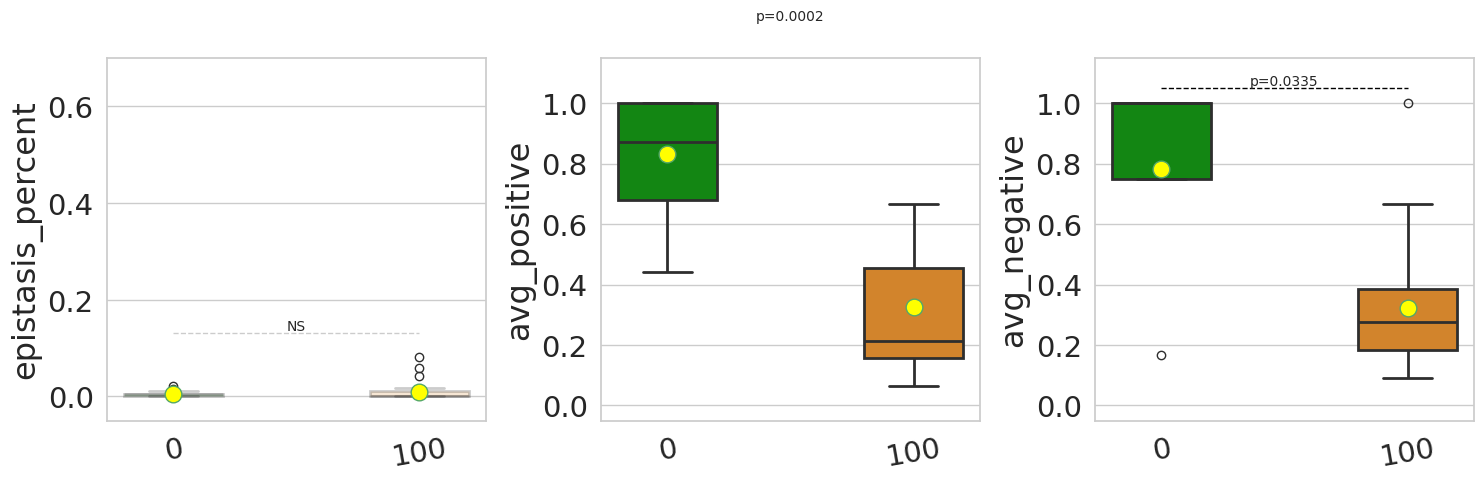

>> reg2m2


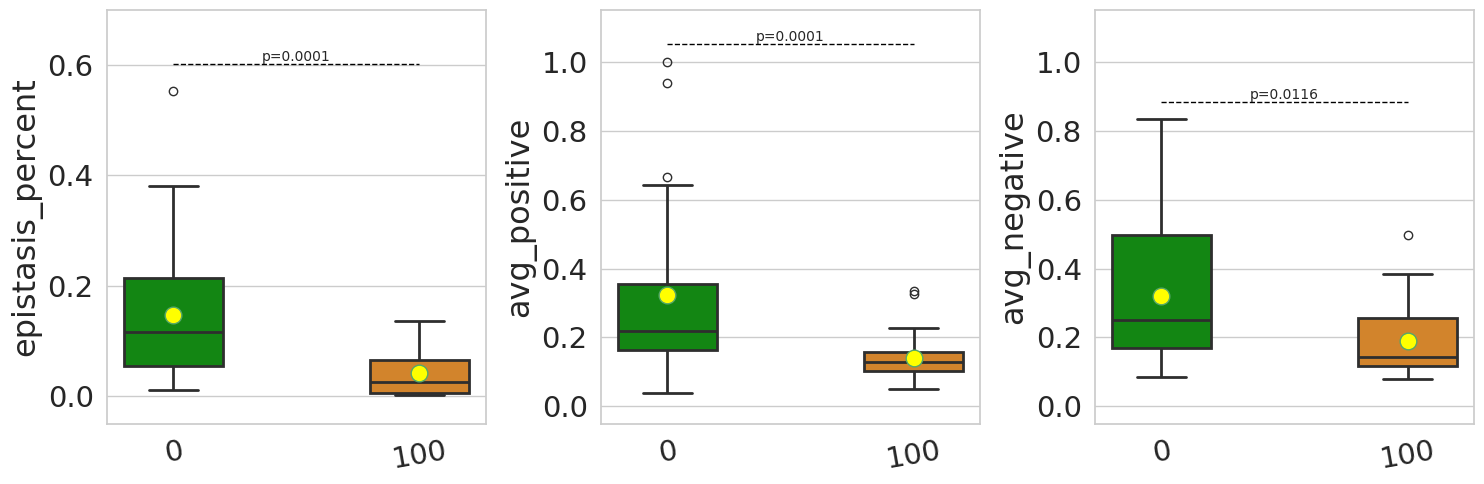

>>>>> proportion
>> reg10m2


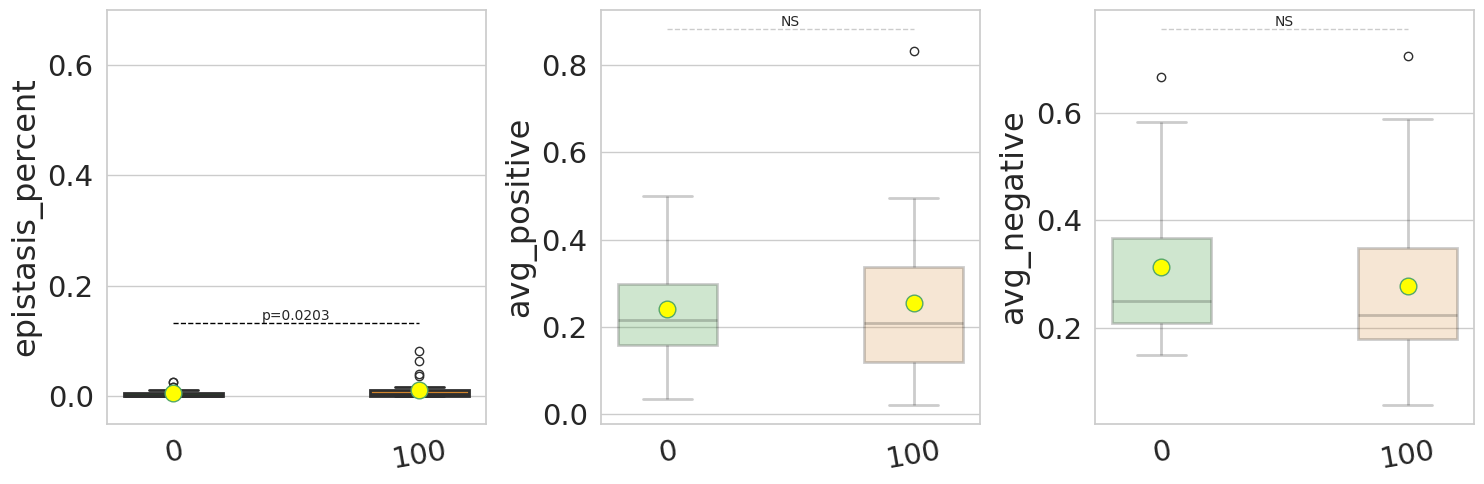

>> reg2m2


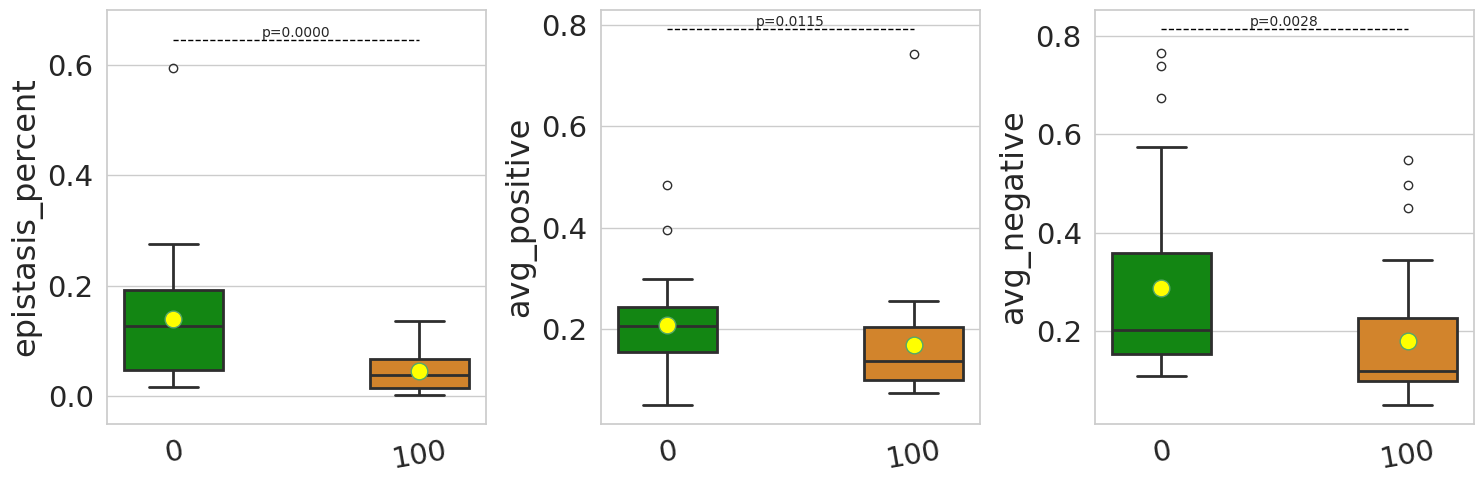

>>>>> coverage
>> reg10m2


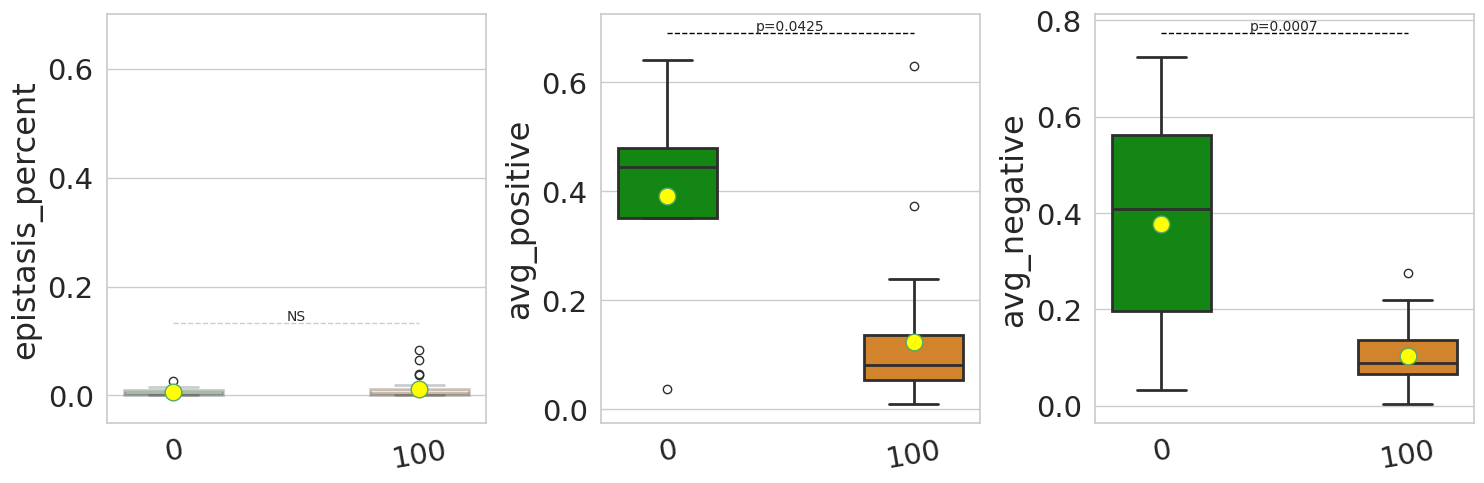

>> reg2m2


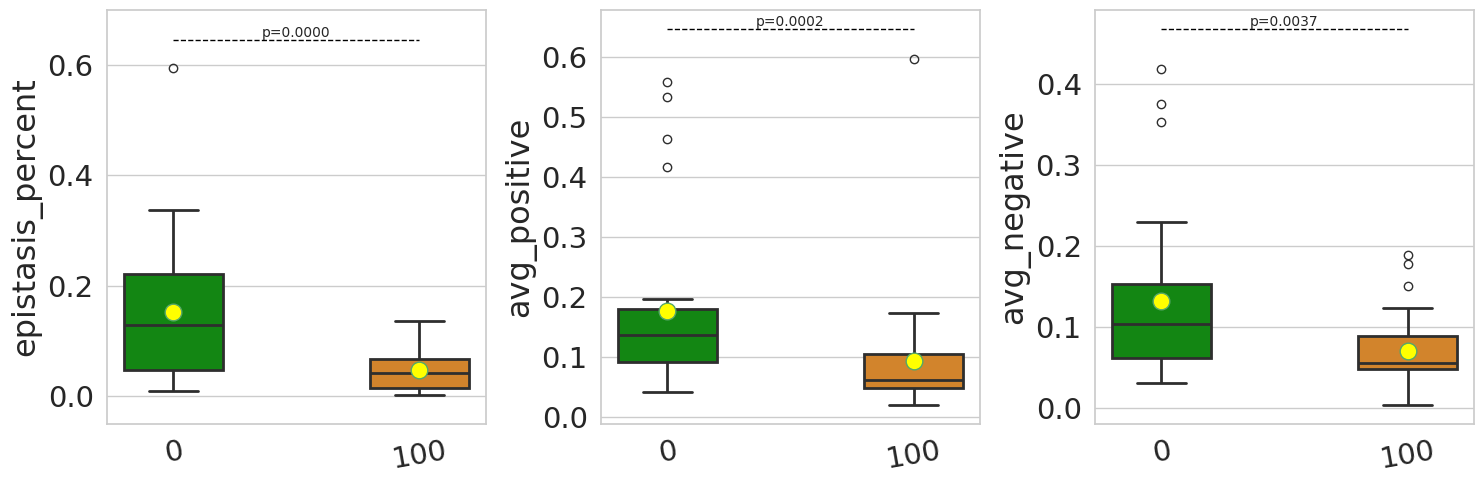

>>>>> extensiveness_prop
>> reg10m2


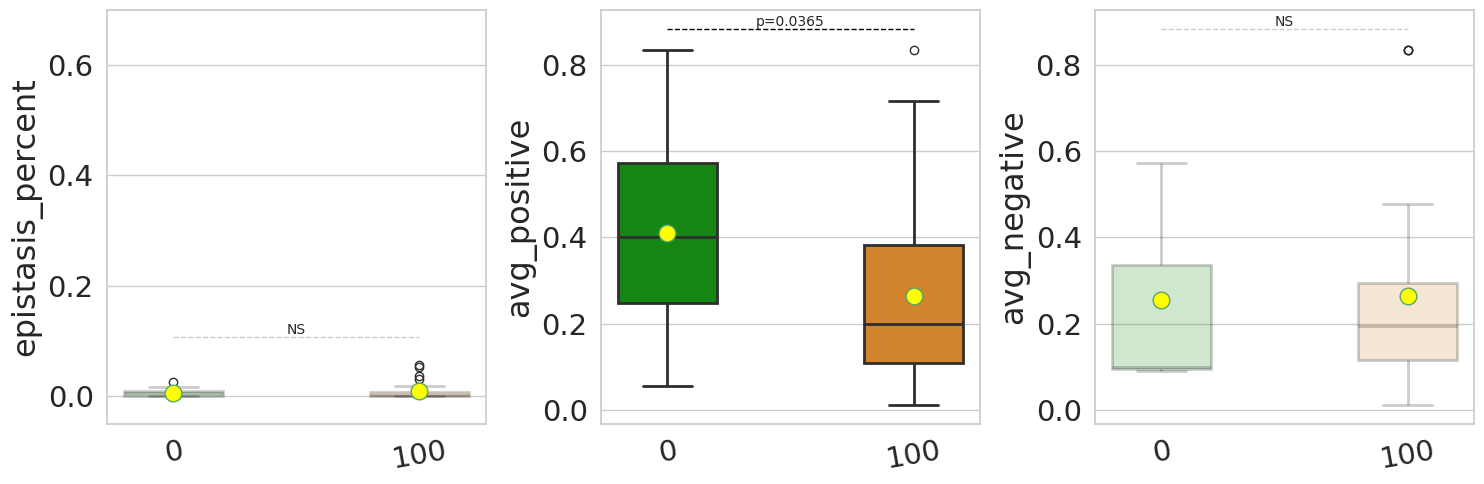

>> reg2m2


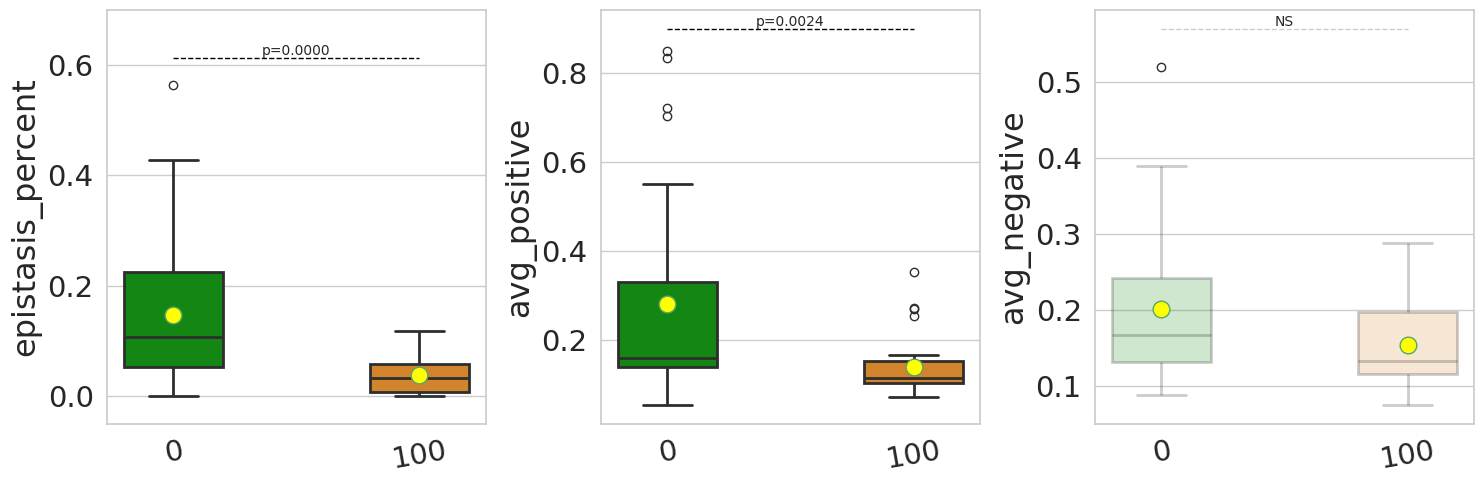

>>>>> branching_prop
>> reg10m2


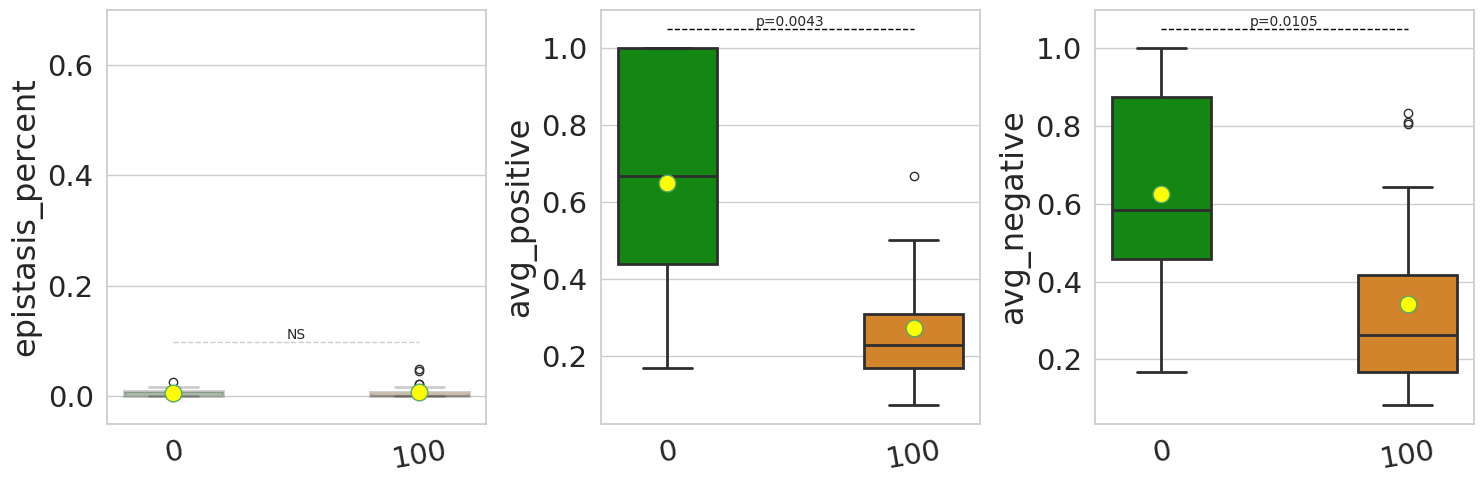

>> reg2m2


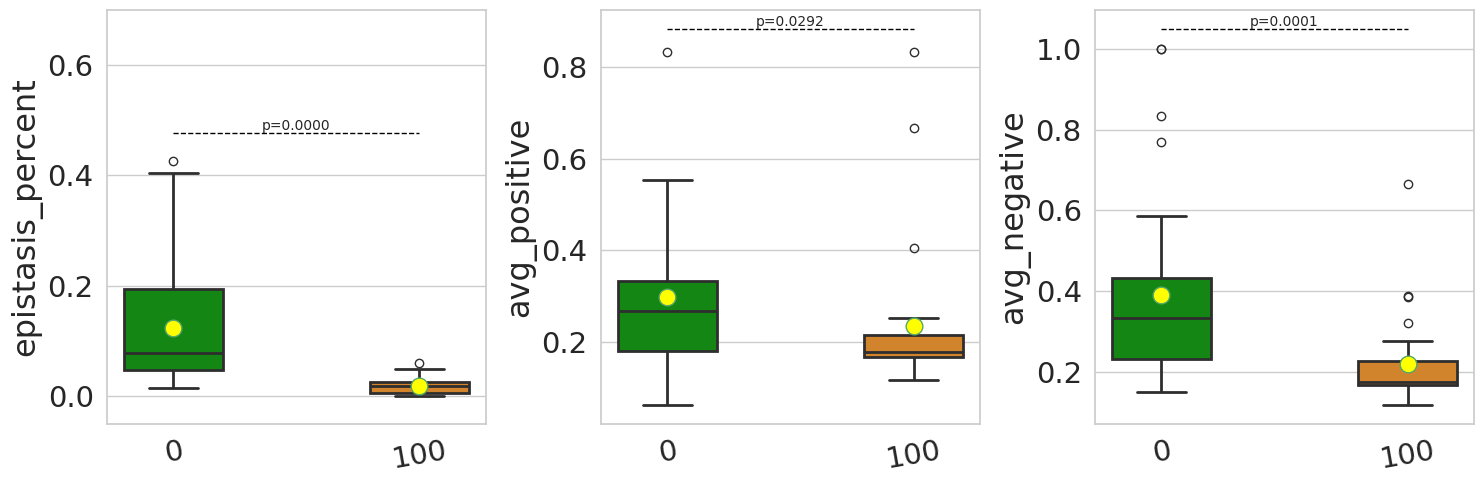

>>>>> modules_count
>> reg10m2


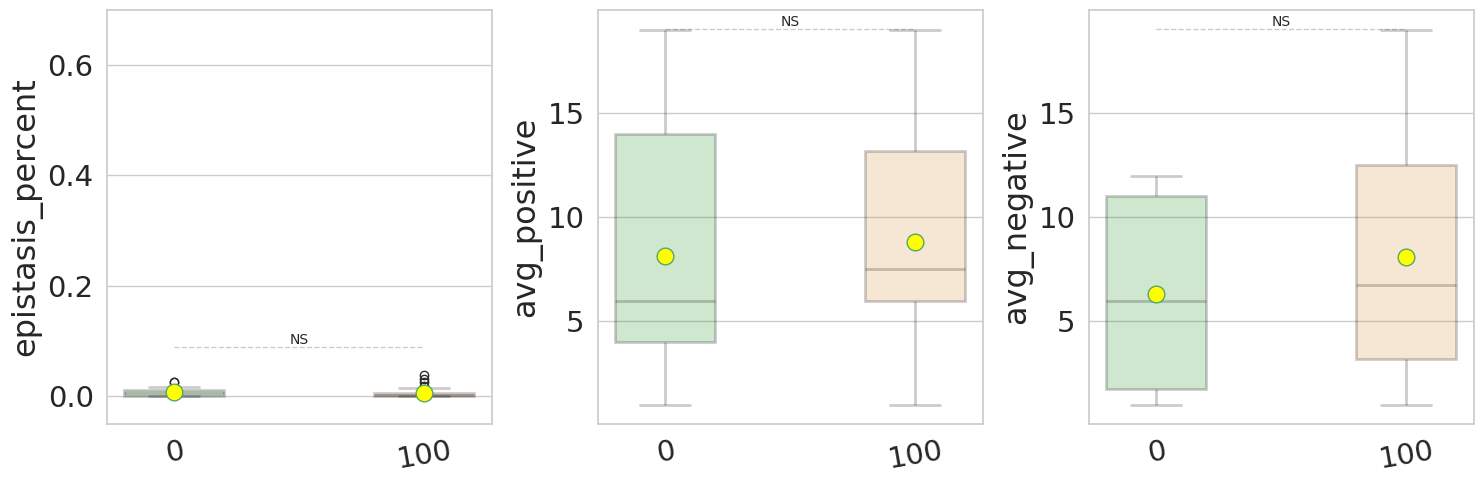

>> reg2m2


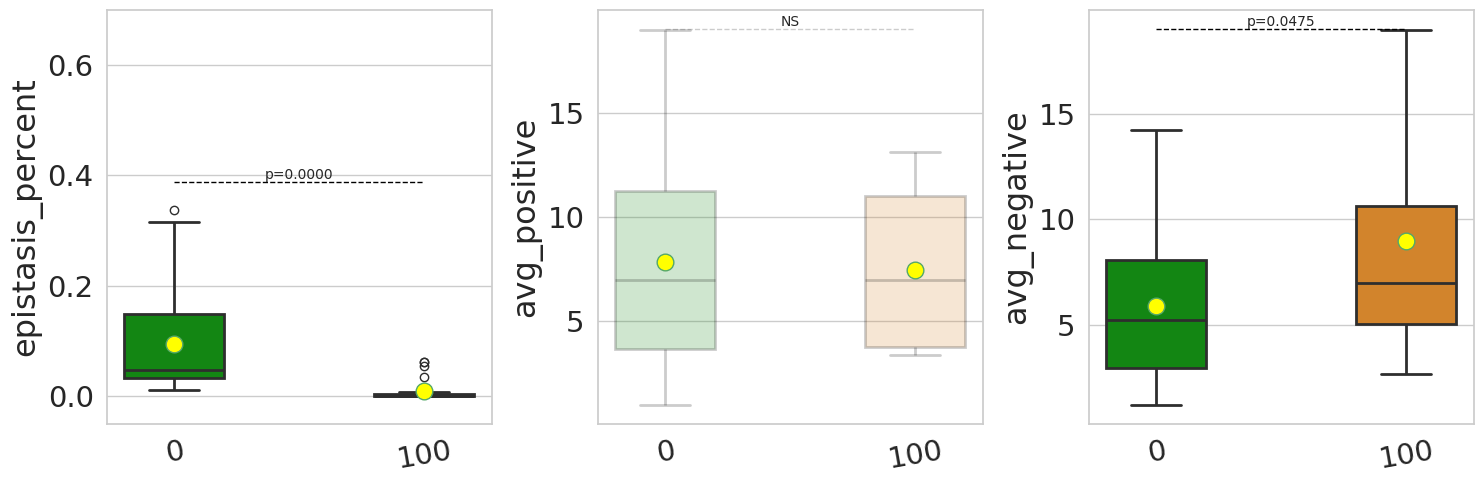

>>>>> hinge_prop
>> reg10m2


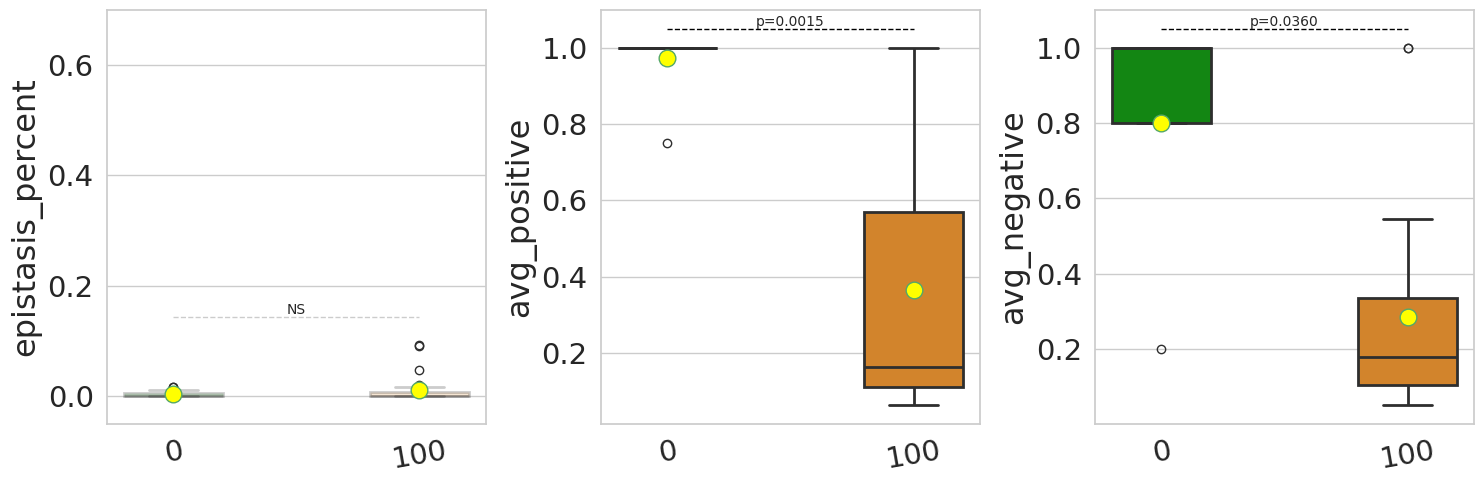

>> reg2m2


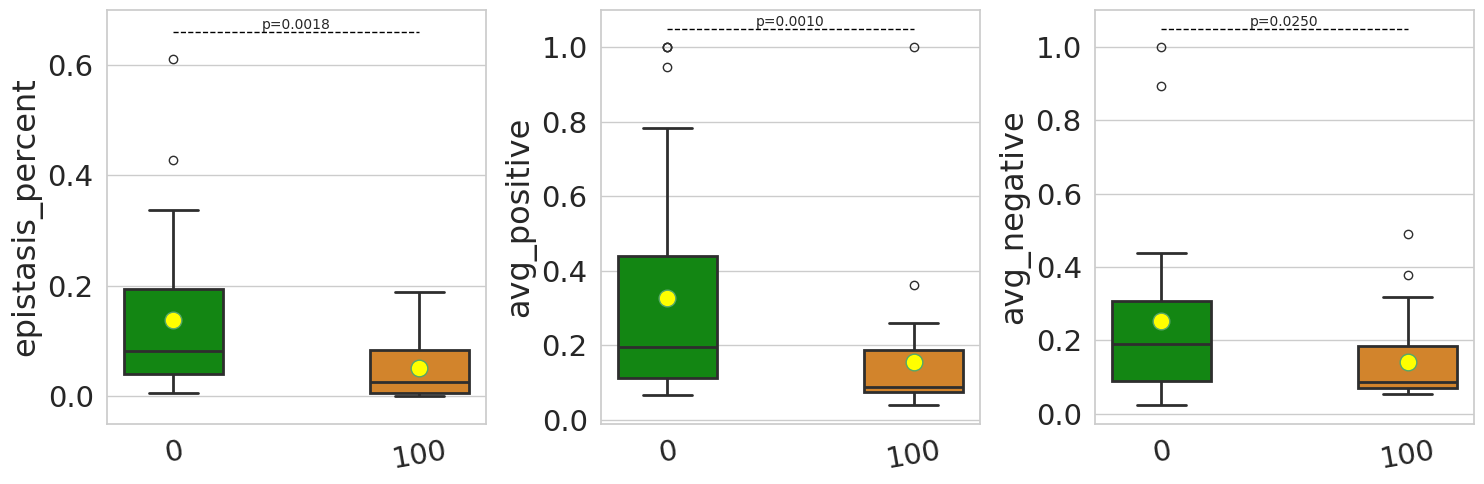

In [522]:


### EPISTASIS CHANGES g1/g100: raw data ###

clrs = ['#009900',
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_traits[trait].copy(deep=True)
    

    for exp in experiments:
        print('>>',exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
        sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
        sb.set_style("whitegrid")
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
           # print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='gen', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)

            y_max = filtered_clean[f'{metric}'].max() + 0.05  #
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
            
            if metric in ['epistasis_percent']:
                ax.set_ylim(-0.05, 0.7)

            if metric == 'avg_positive' or metric == 'avg_negative':
                if trait in avg_pos_scale.keys():
                    ax.set_ylim(avg_pos_scale[trait][0], avg_pos_scale[trait][1])
      
            ax.tick_params(axis='x', labelrotation=10)
            
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')
       
        plt.tight_layout()
        plt.show()







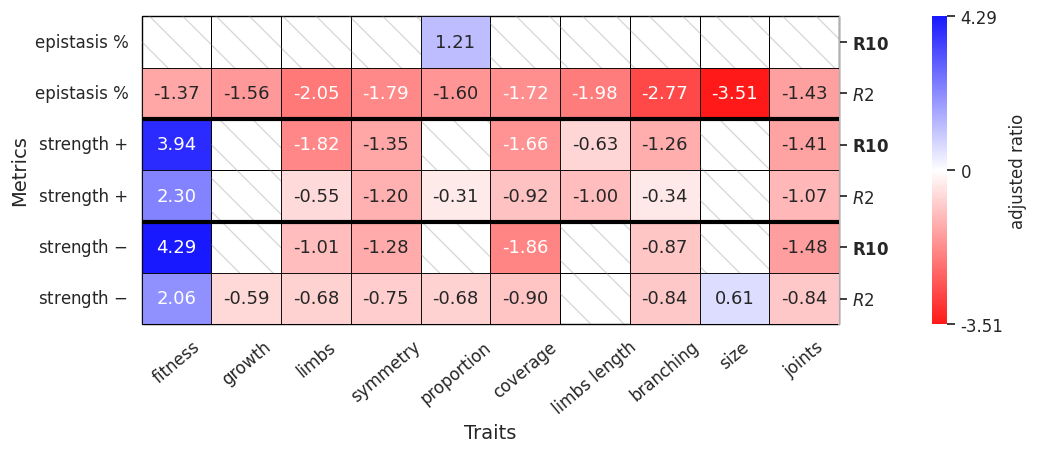

In [523]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.patches as patches

generations = [0, 100]

# Store ratio values for each metric, trait, and generation
heatmap_data = np.zeros((len(metrics) * len(experiments), len(traits)))
heatmap_p = np.zeros((len(metrics) * len(experiments), len(traits)))
annot_data = np.empty((len(metrics) * len(experiments), len(traits)), dtype=object)

row_labels = []
exp_labels_local = []

for i, metric in enumerate(metrics):
    for exp_idx, exp in enumerate(experiments):
        row_index = i * len(experiments) + exp_idx
        row_labels.append(f"{metric}")
        
        if exp == 'reg10m2':
            exp_labels_local.append(rf'$\mathbf{{{exp_labels[exp_idx]}}}$')
        else:
            exp_labels_local.append(rf'$\mathit{{{exp_labels[exp_idx]}}}$')
        
        for j, trait in enumerate(traits):
            df_trait = df_traits[trait].copy(deep=True)
            df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            # Calculate the averages
            avg_ini_gen = ini_gen.mean()
            avg_end_gen = end_gen.mean()

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')

            # Calculate the ratio of gen 100 by gen 0
         #   perc = (( avg_end_gen/ avg_ini_gen)-1) * 100
            log2_tansf = round(np.log2(avg_end_gen/ avg_ini_gen),2)

            # Store in heatmap data
            heatmap_data[row_index, j] = log2_tansf
            heatmap_p[row_index, j] = p_value
           # annot_data[row_index, j] =  f"{perc:.0f}%"
            annot_data[row_index, j] =  f"{log2_tansf:.2f}"


# Ensure finite values
heatmap_data = np.nan_to_num(heatmap_data, nan=0, posinf=np.nanmax(heatmap_data[np.isfinite(heatmap_data)]), neginf=np.nanmin(heatmap_data[np.isfinite(heatmap_data)]))

# Determine dynamic min and max values for normalization
vmin = np.min(heatmap_data)
vmax = np.max(heatmap_data)

# Create a colormap transitioning from red (negative values) to white (zero) to green (positive values)
cmap = LinearSegmentedColormap.from_list(    "red_white_blue", ["red", "#ffffff", "blue"])

# Normalize the colormap with zero as the midpoint
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Create mask for non-significant values
mask_pvalue = heatmap_p > 0.05

fig, ax = plt.subplots(figsize=(12, 4))

# Plot the consolidated heatmap
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 13},
    xticklabels=traits, yticklabels=row_labels,
    ax=ax, mask=mask_pvalue, norm=norm,
    #cbar_kws={'label': r'Percentage difference ', 'pad': 0.1}
    cbar_kws={'label': r'adjusted ratio', 'pad': 0.1}
)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask_pvalue[i, j]:
            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0, edgecolor='grey',
                facecolor='none', hatch='\\' , alpha=0.3
            )
            ax.add_patch(rect)

# Remove grid lines
ax.set_xticks(ax.get_xticks(), minor=True)
ax.grid(False)

# Set x tick labels
ax.set_xticklabels(traits_labels, rotation=40, fontsize=12)

# Adjust y-axis labels
ax.set_yticklabels(np.repeat(metric_labels, 2), rotation=0, ha='right', fontsize=12)
ax2 = ax.secondary_yaxis('right')
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(exp_labels_local, rotation=0, ha='left', fontsize=12)

# Adjust color bar tick and label sizes
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.label.set_size(12)

# Ensure thick separating lines every two rows
for y in range(2, heatmap_data.shape[0], 2):
    ax.axhline(y=y, color='black', linewidth=3)

# Ensure bottom margin border is present
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1)


# Set the ticks and labels for the colorbar
#colorbar_ticks = [-91,0,1859] 
colorbar_ticks = [-3.51, 0, 4.29] 
cbar.set_ticks(colorbar_ticks)
#cbar.set_ticklabels([f"{int(tick)}%" for tick in colorbar_ticks])
cbar.set_ticklabels([f"{tick}" for tick in colorbar_ticks])

plt.xlabel("Traits",fontsize=14)
plt.ylabel("Metrics",fontsize=14)

# Show the plot
plt.show()

# Save the figure
fig.savefig(f'{path}/knockouts/epistasis_change_G100G0.png', dpi=300, bbox_inches='tight')


>> reg10m2


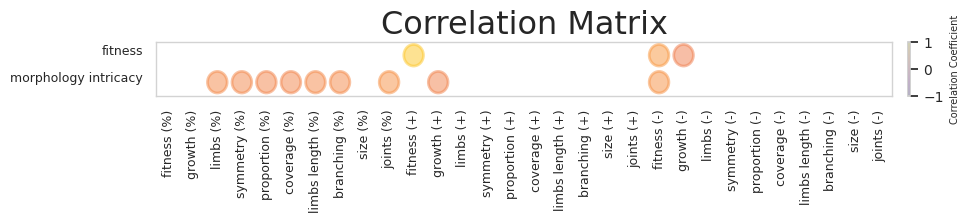

>> reg2m2


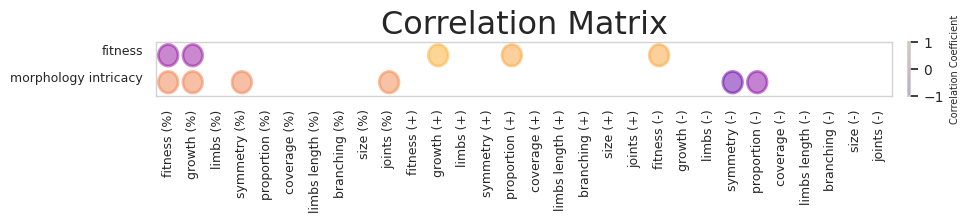

In [524]:
### CORRELATIONS: EPISTASIS VS PHENOCOMPLEXITY

df_complexity_end = df_complexity_all[(df_complexity_all['gen'] == 100)]

metrics1 = ['complexity_env', 'disp_y'] 
additional_columns = []
metrics2 = []
metrics2_adjusted = []
metrics1_adjusted = [  'morphology intricacy', 'fitness'] 

additional_columns_adjusted = []

for idx,trait in enumerate(traits):

    df_trait = df_traits[trait].copy(deep=True) 
    df_trait = df_trait.drop(columns=['Unnamed: 0'])

    corr_df = pd.merge(df_complexity_end, df_trait, on=keys, how='inner')
    corr_df = corr_df.rename(columns={'epistasis_percent': 'epistasis_percent_'+trait, 
                                      'avg_positive': 'avg_positive_'+trait, 
                                      'avg_negative': 'avg_negative_'+trait})
    metrics2.append('epistasis_percent_'+trait)
    metrics2.append('avg_positive_'+trait)
    metrics2.append('avg_negative_'+trait)
    metrics2_adjusted.append(traits_labels[idx]+' (%)')
    metrics2_adjusted.append(traits_labels[idx]+ ' (+)')
    metrics2_adjusted.append(traits_labels[idx]+ ' (-)')
   
    obsolete_vars = ['symmetry', 'extremities_prop' ,'neutral', 'positive', 'negative', 'epistasis']
    redudant_vars = [ 'ranking', 'disp_y', 'geno_size', 'n_genes' ,'complexity_env',
                     'complexity_branch', 'complexity_net', 'interactions_density', 'zero_regulators']

    if idx == 0:
        corr_df_all = corr_df.drop(columns=obsolete_vars)
    else:
        corr_df = corr_df.drop(columns=obsolete_vars+redudant_vars)
        corr_df_all = pd.merge(corr_df_all, corr_df, on=keys, how='inner')
  
for idx_experiment, exp in enumerate(experiments):
    print('>>', exp)
    df_complexity_end_exp = corr_df_all[(corr_df_all['experiment_name'] == exp)]
    df_complexity_end_exp = df_complexity_end_exp[ (df_complexity_end_exp['ranking'] == 'best') ] 
    df_complexity_end_exp[df_complexity_end_exp.select_dtypes(include=['number']).columns] = \
                df_complexity_end_exp.select_dtypes(include=['number']).fillna(0)

    def darken_color(color, factor=0.5):
        r, g, b, a = mcolors.to_rgba(color)
        return mcolors.to_hex((r * factor, g * factor, b * factor, a))
    
    # Function to calculate correlation and p-values
    def calculate_corr_and_pvalues(df):
        corr_matrix = df.corr()
        p_values = pd.DataFrame(np.zeros_like(corr_matrix, dtype=float), index=corr_matrix.index, columns=corr_matrix.columns)
        
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                if i != j:
                    corr, p_value = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_values.iloc[i, j] = p_value
                    if p_value < 0.05:
                        pass
                        #print(corr_matrix.columns[i], corr_matrix.columns[j], corr, p_value)
                else:
                    p_values.iloc[i, j] = np.nan  # No p-value for self-correlation
    
        return corr_matrix, p_values
    


    # Compute correlations and p-values
    corr_matrix, p_values = calculate_corr_and_pvalues(df_complexity_end_exp[metrics1 + metrics2])
    
    original_names = metrics1 + metrics2 + additional_columns
    adjusted_names = metrics1_adjusted + metrics2_adjusted + additional_columns_adjusted
    rename_mapping = {original: adjusted for original, adjusted in zip(original_names, adjusted_names)}
    
    corr_matrix = corr_matrix.rename(columns=rename_mapping, index=rename_mapping)
    p_values = p_values.rename(columns=rename_mapping, index=rename_mapping)
    
    # Reorder metrics2_adjusted
    percent_labels = [label for label in metrics2_adjusted if '(%)' in label]
    plus_labels = [label for label in metrics2_adjusted if '(+)' in label]
    minus_labels = [label for label in metrics2_adjusted if '(-)' in label]
    
    metrics2_adjusted_sorted = percent_labels + plus_labels + minus_labels + additional_columns_adjusted
    
    # Select the relevant portion of the correlation matrix with reordered x-axis
    corr_matrix = corr_matrix.loc[metrics1_adjusted, metrics2_adjusted_sorted]
    p_values = p_values.loc[metrics1_adjusted, metrics2_adjusted_sorted]
    
    # Create a mask for significant correlations
    significance_mask = p_values < 0.05

    
    # Create a color map from blue to red
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'blue_red',
        ['blue', 'white', 'red'],
        N=256
    )
    cmap = plt.get_cmap('plasma')
    
    # Plotting ########
    plt.figure(figsize=(10, 0.7))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('#D3D3D3')   # Set the color for all spines
        spine.set_linewidth(1) 
    
    # Draw the circles for significant correlations
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            if significance_mask.iloc[i, j]:

                rect_color = cmap((corr_matrix.iloc[i, j] + 1) / 2)  # Normalize correlation to [0, 1]
                border_color = darken_color(rect_color, factor=0.7)  # Darken the fill color for border

                rect = plt.Circle((j, i),  0.40, color=rect_color, alpha=0.5, edgecolor=border_color, linewidth=2, zorder=10)
                ax.add_patch(rect)
             #   plt.text(j , i + 0.2, f'{corr_matrix.iloc[i, j]:.2f}', color='black',     ha='center', va='center', fontsize=6, zorder=20)

    # Set the labels and limits
    plt.xticks(ticks=np.arange(len(corr_matrix.columns)) , labels=corr_matrix.columns, rotation=90, fontsize=9)
    plt.yticks(ticks=np.arange(len(corr_matrix.index))+0.2  , labels=corr_matrix.index, fontsize=9)
   
    plt.xlim(-0.5, len(corr_matrix.columns) - 0.5)
    plt.ylim(len(corr_matrix.index) - 0.5, -0.5)

    plt.title('Correlation Matrix')
    plt.grid(False)
    plt.gca().invert_yaxis()

    # Create and add color bar
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Correlation Coefficient', fontsize=7)
    
    plt.savefig(f'{path}/knockouts/corr_{exp}.png', dpi=300, bbox_inches='tight')
    plt.show()



 >>>>> metrics_dist disp_y

   >>> metric_order avg_positive_disp_y

 -- reg10m2
Average first : 1.1605089848590682
Average second : 1.9608992196541901
  p-value: 0.0001


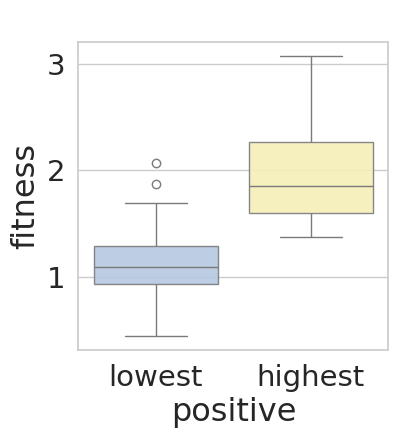


 -- reg2m2
Average first : 2.058426174079068
Average second : 2.2239852293161664
  p-value: 0.3404


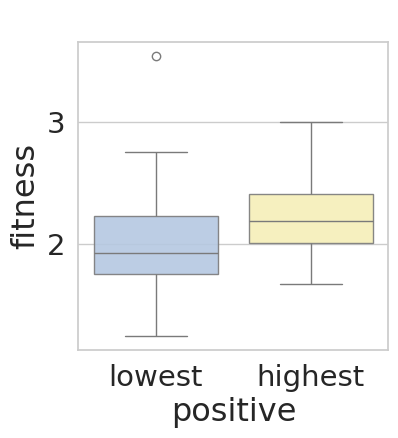


   >>> metric_order avg_negative_disp_y

 -- reg10m2
Average first : 1.2530223894079737
Average second : 1.8683858151052846
  p-value: 0.0044


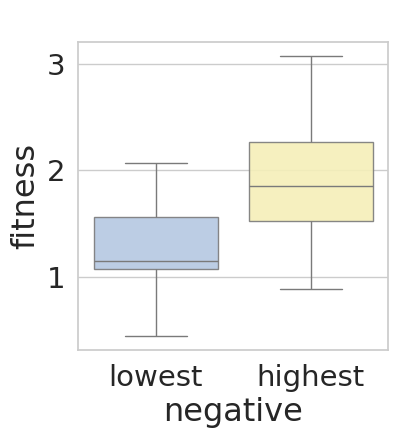


 -- reg2m2
Average first : 2.04878273292755
Average second : 2.2336286704676853
  p-value: 0.2861


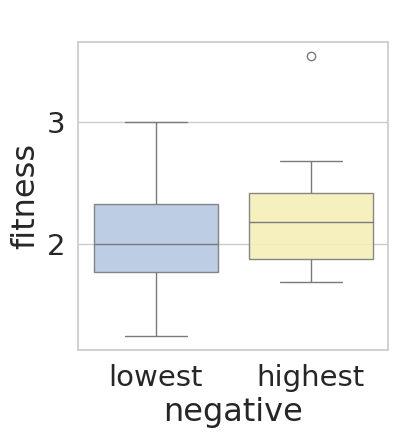

In [525]:

### epistais vs fit


metrics_dist = ['disp_y']
metrics_order = ['avg_positive_disp_y', 'avg_negative_disp_y']#,'epistasis_percent_disp_y' ]
metrics_order_l = ['positive', 'negative']

for metric_dist in metrics_dist:
    print(f'\n >>>>> metrics_dist',metric_dist)
    for mi, metric_order in enumerate(metrics_order):
        print(f'\n   >>> metric_order',metric_order)
        for exp in experiments:
            print('\n --',exp)
            df_comp_g = corr_df_all[ (corr_df_all['experiment_name'] == exp) ] 
            df_comp_g[df_comp_g.select_dtypes(include=['number']).columns] = \
                    df_comp_g.select_dtypes(include=['number']).fillna(0)
            df_comp_g = df_comp_g[ (df_comp_g['ranking'] == 'best') ] 
            df_sorted = df_comp_g.sort_values(by=metric_order).reset_index(drop=True)
                   
    
            midpoint = len(df_sorted) // 2
            first_half = df_sorted.iloc[:midpoint]
            second_half = df_sorted.iloc[midpoint:]
            
            # Calculate and display the averages for 'b' in each half
            avg_first_half = first_half[metric_dist].mean()
            avg_second_half = second_half[metric_dist].mean()
     
            print(f"Average first : {avg_first_half}")
            print(f"Average second : {avg_second_half}")
            
            t_stat, p_value = ttest_ind(first_half[metric_dist], second_half[metric_dist], equal_var=True)
    
            #_, p_value = mannwhitneyu(first_half[metric_dist], second_half[metric_dist], alternative='two-sided')
            print(f"  p-value: {round(p_value, 4)}")
            
            # Add a new column to each half to indicate "First Half" or "Second Half"
            first_half['half'] = 'lowest'
            second_half['half'] = 'highest'
            
            #  Concatenate the two halves back into a single DataFrame
            df_concat = pd.concat([first_half, second_half], ignore_index=True)
            
            # Plot variable 'disp_y' for each half using box plots
            plt.figure(figsize=(4, 4))
            sb.boxplot(x='half', y=metric_dist, data=df_concat, palette=["#aec7e8", "#fff7ae"], boxprops=dict(alpha=0.9) )

            plt.xlabel(metrics_order_l[mi])
            plt.ylabel("fitness")
            plt.title(' ')
            plt.savefig(f'{path}/knockouts/epis_fit_{metric_order}_{exp}.png', dpi=300, bbox_inches='tight')
            plt.show() 


>>>>> disp_y
>> reg10m2


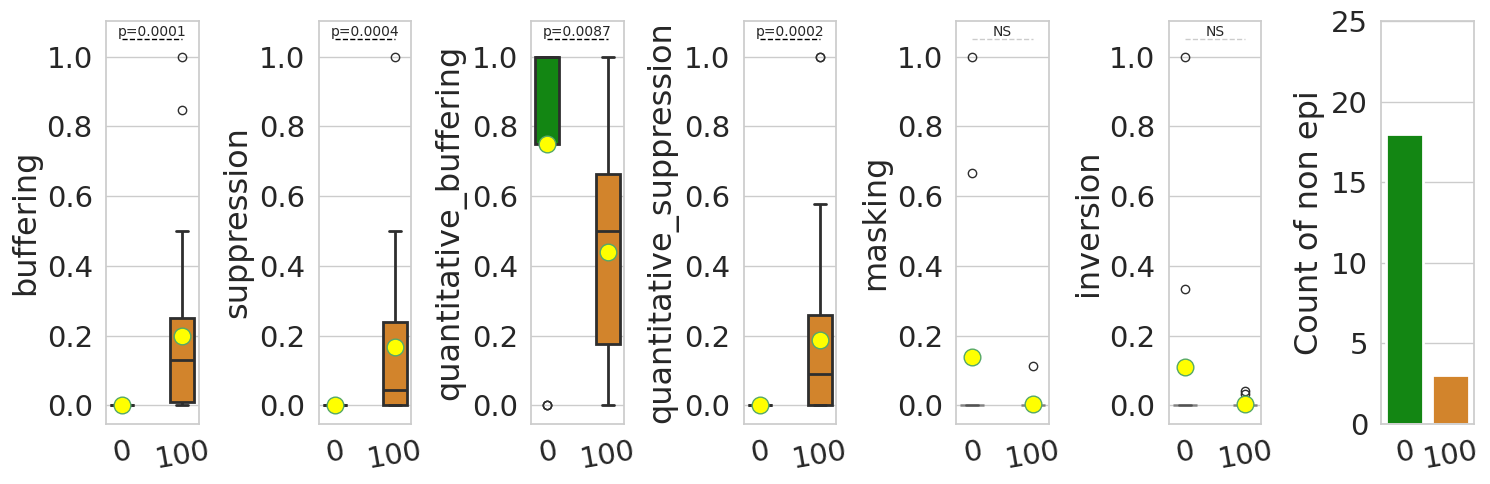

>> reg2m2


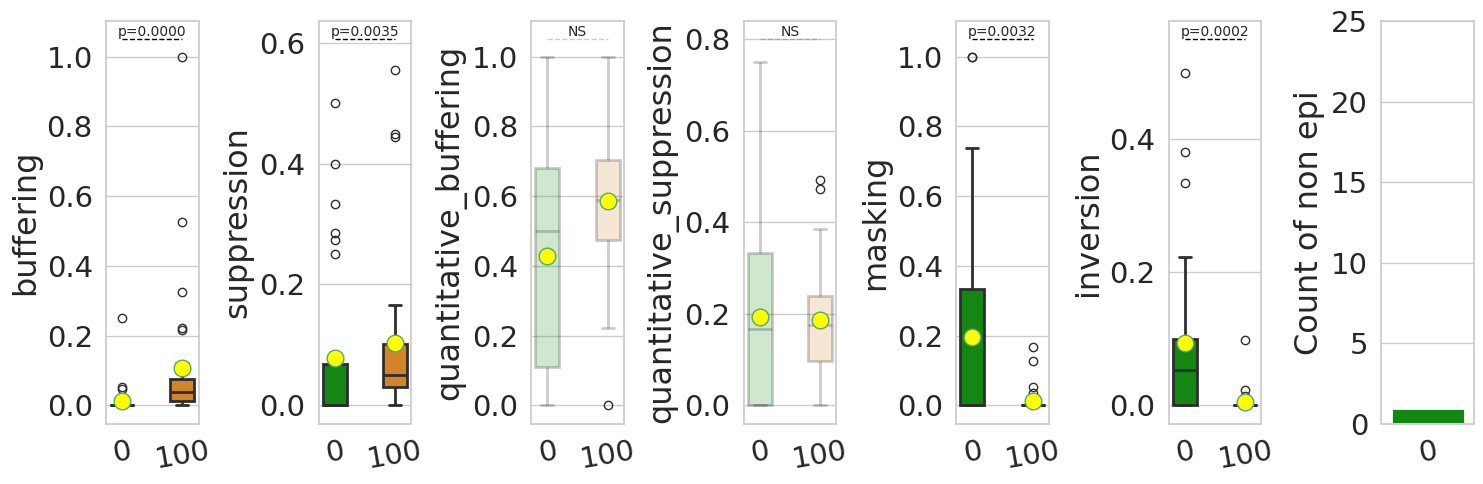

>>>>> distance
>> reg10m2


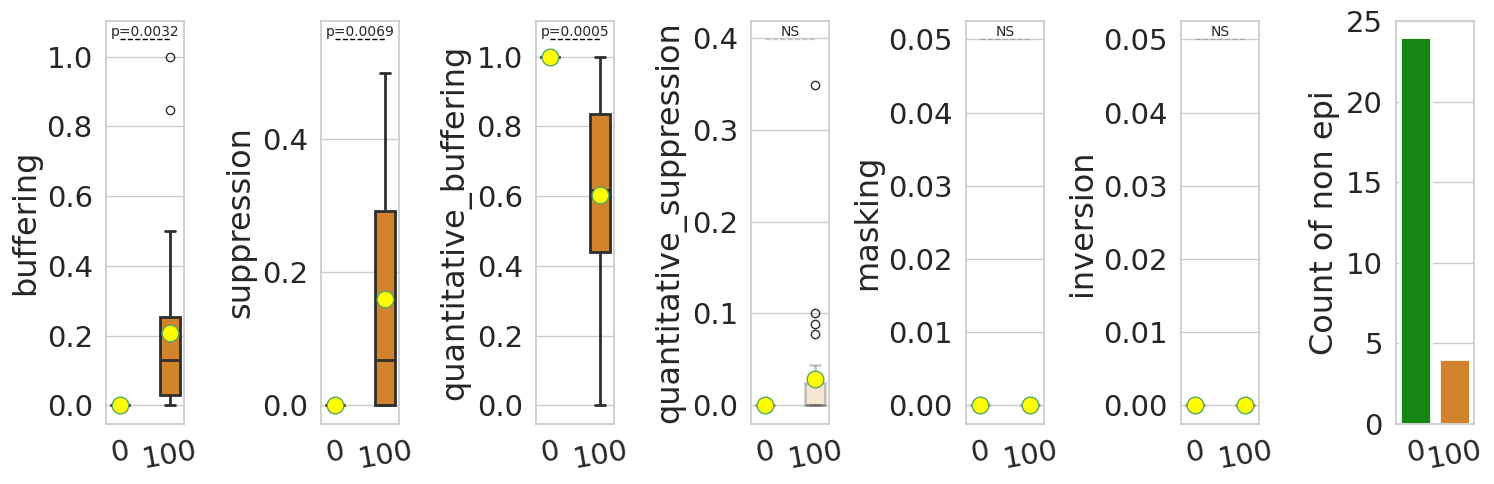

>> reg2m2


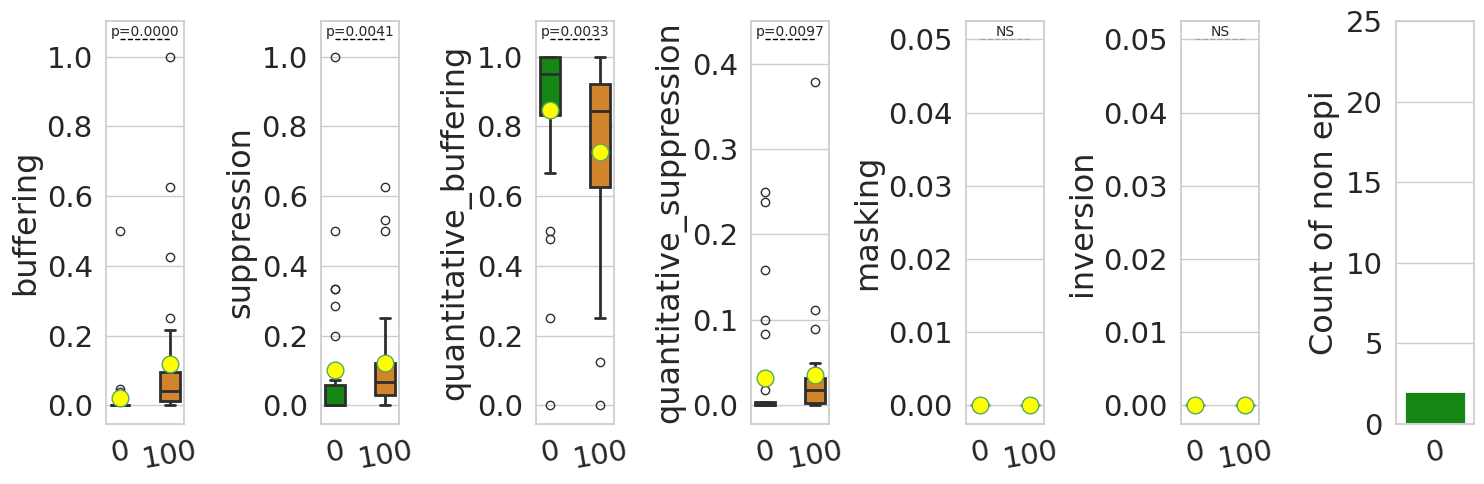

In [526]:
### EPISTASIS CATEG CHANGES ###
traits = ['disp_y', 'distance' ]

metrics = ['buffering', 'suppression', 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion']

clrs = ['#009900',

        
        '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4],'extremities_prop': [-0.05, 1.1],'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}

sb.set(rc={"axes.titlesize": 23, "axes.labelsize": 23, 'ytick.labelsize': 21, 'xtick.labelsize': 21})
sb.set_style("whitegrid")

for trait in traits:
    print('>>>>>',trait)
    df_trait = df_categ_traits[trait].copy(deep=True)
    
    for exp in experiments:
        print('>>',exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[ (df_trait_exp['ranking'] == 'best') ] 
   
        df_trait_exp_zero = df_trait_exp[ (df_trait_exp['epistasis'] == 0) ] 
        df_trait_exp = df_trait_exp[ (df_trait_exp['epistasis'] > 0) ] 
       
        df_trait_exp[metrics] = df_trait_exp[metrics].fillna(0)
        
        fig, axes = plt.subplots(1, 7, figsize=(15, 5))  #
       
        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']

            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
            #print(f"\nMetric: {metric}, p-value: {round(p_value, 4)}")

            sb.boxplot(x='gen', y=f'{metric}', data=filtered_clean,
                       palette=clrs, width=0.4, showmeans=True, linewidth=2, fliersize=6,
                       meanprops={"marker": "o", "markerfacecolor": "yellow", "markersize": "12"}, ax=ax)
    
            y_max = filtered_clean[f'{metric}'].max() + 0.05             
            x_positions = [0, 1]  
            ax.plot(x_positions, [y_max, y_max], color='black', linestyle='--', linewidth=1)
            if p_value >= 0.05:
                sig = 'NS'
                alpha = 0.2
                for patch in ax.patches:
                    patch.set_alpha(alpha)
                    patch.set_edgecolor((0.0, 0.0, 0.0, alpha))  # Example RGBA border color
                for line in ax.lines:
                    if line.get_linestyle() == '-' or line.get_linestyle() == '--':
                        line.set_color((0.0, 0.0, 0.0, alpha))  
                 
            else:
                sig = f'p={p_value:.4f}'
            ax.text(x=0.5, y=y_max, s=sig, ha='center', va='bottom', fontsize=10)
      
            ax.tick_params(axis='x', labelrotation=10)
            ax.set_xlabel('')
            ax.set_ylabel(f'{metric}')


        ax = axes[idx+1]

        # Create a bar plot to count the number of rows for each 'gen'
        sb.countplot(x='gen', data=df_trait_exp_zero, palette=clrs, linewidth=2, ax=ax)
        
        # Customize the plot
        ax.tick_params(axis='x', labelrotation=10)
        ax.set_xlabel('')
        ax.set_ylabel(f'Count of non epi')
        ax.set_ylim(0, 25) 
        
        # Adjust the layout and display the plot
        plt.tight_layout()
        plt.show()
    


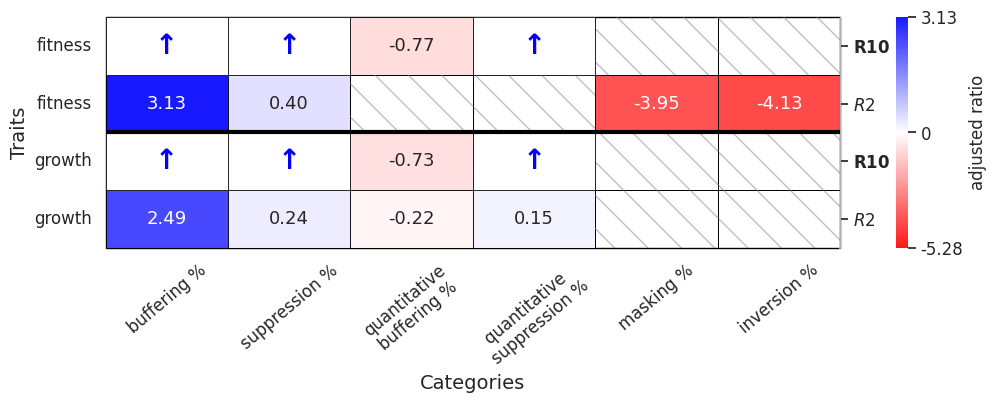

In [527]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
import matplotlib.patches as patches
import math 

generations = [0, 100]

# Store ratio values for each metric, trait, and generation
heatmap_data = np.zeros((len(traits) * len(experiments), len(metrics)))
heatmap_datag0 = np.zeros((len(traits) * len(experiments), len(metrics)))
heatmap_datag100 = np.zeros((len(traits) * len(experiments), len(metrics)))
heatmap_p = np.zeros((len(traits) * len(experiments), len(metrics)))
annot_data = np.empty((len(traits) * len(experiments), len(metrics)), dtype=object)

row_labels = []
exp_labels_local = []

for i, trait in enumerate(traits):
    df_trait = df_categ_traits[trait].copy(deep=True)
    
    for k, exp in enumerate(experiments):
        
        row_index = i * len(experiments) + k
        row_labels.append(f"{trait}")
        
        if exp == 'reg10m2':
            exp_labels_local.append(rf'$\mathbf{{{exp_labels[k]}}}$')
        else:
            exp_labels_local.append(rf'$\mathit{{{exp_labels[k]}}}$')
            
        for j, metric in enumerate(metrics):
       
            df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
            df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']
            
            # only cases with epistasis: when e vision of the categs freq by 0 results is nan
            filtered_clean = df_trait_exp[pd.notna(df_trait_exp[metric])]
            ini_gen = filtered_clean[filtered_clean['gen'] == 0][f'{metric}']
            end_gen = filtered_clean[filtered_clean['gen'] == 100][f'{metric}']
    
            # Calculate the averages
            avg_ini_gen = ini_gen.mean()
            avg_end_gen = end_gen.mean()

            # Perform the Mann-Whitney U test
            _, p_value = mannwhitneyu(ini_gen, end_gen, alternative='two-sided')
         
            # Calculate the ratio of gen 100 to gen 0
           # perc = (( avg_end_gen/ avg_ini_gen)-1) * 100
            log2_tansf = round(np.log2(avg_end_gen/ avg_ini_gen),2)


            # Store in heatmap data
            heatmap_datag0[row_index, j] = avg_ini_gen
            heatmap_datag100[row_index, j] = avg_end_gen
            
            heatmap_data[row_index, j] = log2_tansf
            heatmap_p[row_index, j] = p_value
          #  annot_data[row_index, j] =  f"{perc:.0f}%"
            annot_data[row_index, j] =  f"{log2_tansf:.2f}"

metrics_labels=['buffering %', 'suppression %' , 'quantitative\nbuffering %', 'quantitative \nsuppression %', 
                'masking %', 'inversion %'] 
#metrics_labels=['buffering (B) %', 'suppression (S) %' , 'quantitative\nbuffering (QB) %', 'quantitative \nsuppression (QS) %', 
               # 'masking (M) %', 'inversion (I) %'] 

traits_labels = traits_labels[0:2]

# Ensure finite values (removing Inf and NaN)
heatmap_data = np.nan_to_num(heatmap_data, nan=0, posinf=np.nan, neginf=np.nan)

# Determine dynamic min and max values for normalization
vmin = np.nanmin(heatmap_data)
vmax = np.nanmax(heatmap_data)

# Create a colormap transitioning from red (negative values) to white (zero) to green (positive values)
cmap = LinearSegmentedColormap.from_list(    "red_white_blue", ["red", "#ffffff", "blue"])


# Normalize the colormap with zero as the midpoint
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Create mask for non-significant values
mask_pvalue = heatmap_p > 0.05

fig, ax = plt.subplots(figsize=(12, 3))

# Plot the consolidated heatmap
sns.heatmap(
    heatmap_data, annot=annot_data, fmt="",
    cmap=cmap, linewidths=0.5, linecolor='black',
    alpha=0.9, annot_kws={'size': 13},
    xticklabels=metrics_labels, yticklabels=row_labels,
    ax=ax, mask=mask_pvalue, norm=norm,
    #cbar_kws={'label': r'Percentage difference ', 'pad': 0.06}
    cbar_kws={'label': r'adjusted ratio', 'pad': 0.06}
)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if mask_pvalue[i, j]:
            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0, edgecolor='grey',
                facecolor='none', hatch='\\' , alpha=0.5
            )
            ax.add_patch(rect)

# Overlay crosshatching for non-significant p-values (p > 0.05)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
       # if theres was nothing in that category but now theres something
        if heatmap_datag0[i, j] == 0 and heatmap_datag100[i, j] > 0:
            ax.annotate('↑', (j + 0.5, i + 0.5), color='blue', fontsize=20, ha='center', va='center', fontweight='bold')

            rect = patches.Rectangle(
                (j, i), 1, 1, linewidth=0.5, edgecolor='black',
                facecolor='white', ##0000CC'
            )
            ax.add_patch(rect)

# Remove grid lines
ax.set_xticks(ax.get_xticks(), minor=True)
ax.grid(False)
 
# Set x tick labels to font size 12
ax.set_xticklabels(metrics_labels, rotation=40, fontsize=12)

# Adjust y-axis labels: primary labels (e.g., metric) on the left...
ax.set_yticklabels(np.repeat(traits_labels, 2), rotation=0, ha='right', fontsize=12)
# ...and a secondary y-axis for the generation labels on the right
ax2 = ax.secondary_yaxis('right')
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(exp_labels_local, rotation=0, ha='left', fontsize=12)

# Adjust color bar tick and label sizes
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.label.set_size(12)

# Ensure thick separating lines every two rows
for y in range(2, heatmap_data.shape[0], 2):
    ax.axhline(y=y, color='black', linewidth=3)

# Ensure bottom margin border is present
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(1)

# Set the ticks and labels for the colorbar
#colorbar_ticks = [-50, 0, 100] 
colorbar_ticks = [vmin, 0, vmax] 
cbar.set_ticks(colorbar_ticks)
#cbar.set_ticklabels([f"    " for tick in colorbar_ticks])
cbar.set_ticklabels([f"{tick}" for tick in colorbar_ticks])

# # Add x and y labels with desired font size
plt.xlabel("Categories", fontsize=14)
plt.ylabel("Traits", fontsize=14)

plt.show()
fig.savefig(f'{path}/knockouts/epistasis_categ_change.png', dpi=300, bbox_inches='tight')


>>>>> disp_y
>> reg10m2
The number of rows in df_trait_exp_zero is: 21


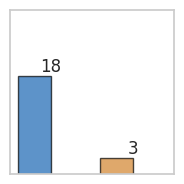

>> reg2m2
The number of rows in df_trait_exp_zero is: 1


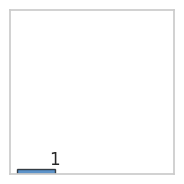

>>>>> distance
>> reg10m2
The number of rows in df_trait_exp_zero is: 28


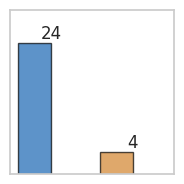

>> reg2m2
The number of rows in df_trait_exp_zero is: 2


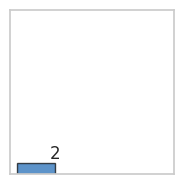

In [528]:

metrics = ['buffering', 'suppression', 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion']

clrs = ['#0066CC', '#EE8610']

avg_pos_scale = {'disp_y': [-0.5, 4], 'extremities_prop': [-0.05, 1.1], 'symmetry': [-0.05, 1.15], 'distance': [-0.5, 25]}


sb.set_style("whitegrid")

for trait in traits:
    print('>>>>>', trait)
    df_trait = df_categ_traits[trait].copy(deep=True)
    
    for exp in experiments:
        print('>>', exp)
        df_trait_exp = df_trait[df_trait['experiment_name'] == exp]
        df_trait_exp = df_trait_exp[df_trait_exp['ranking'] == 'best']
        
        
        df_trait_exp_zero = df_trait_exp[df_trait_exp['epistasis'] == 0]
        
        
        # Count the number of rows in df_trait_exp_zero
        num_rows = df_trait_exp_zero.shape[0]
        print(f'The number of rows in df_trait_exp_zero is: {num_rows}')
        
        if num_rows > 0:
            fig, ax = plt.subplots(1, 1, figsize=(2, 2))

            # Create countplot
            sb.countplot(x='gen', data=df_trait_exp_zero, palette=clrs, linewidth=1, ax=ax, alpha=0.7, edgecolor='black')

            # Set y-axis limit
            ax.set_ylim(0, 30)
            
            # Annotate each bar with its count
            for p in ax.patches:
                height = p.get_height()
                if height > 0:
                    ax.annotate(
                        f'{int(height)}',  # The count
                        (p.get_x() + p.get_width() / 2., height),  # Position at top of bar
                        ha='center', va='bottom',
                        fontsize=12#, fontweight='bold'
                    )
                    
            # Remove x-axis labels
            ax.set_xticklabels([''] * len(ax.get_xticks()))

            # Consistent bar width
            for patch in ax.patches:
                patch.set_width(0.4)  # Adjust width to keep it consistent

            # Add a dummy bar if there's only one bar
            if len(ax.patches) == 1:
                ax.bar(1, 0, width=0.4, color='white', edgecolor='white')  # Invisible bar to maintain spacing

            # Remove y-axis labels
            ax.set_yticklabels([])
            ax.set_xlabel('')
            ax.set_ylabel('')


            
            # Adjust the layout and display the plot
            plt.tight_layout()
            ax.grid(False)
            plt.show()
            
            fig.savefig(f'{path}/knockouts/epistasis_nochange_{trait}_{exp}.png', dpi=300, bbox_inches='tight')

>> reg10m2


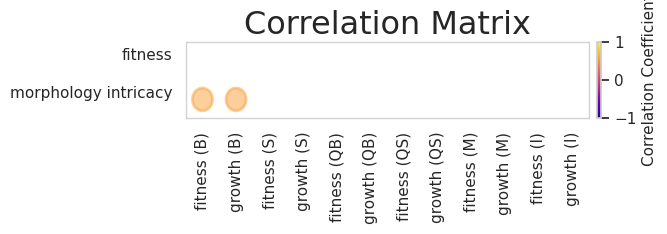

>> reg2m2


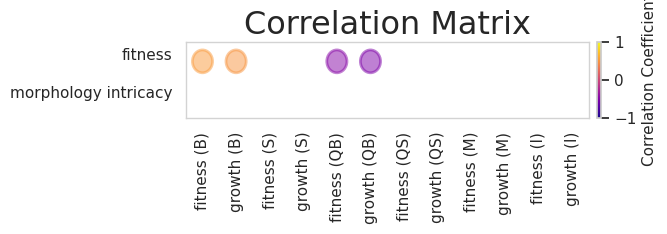

In [529]:
### CORRELATIONS: CATEG EPISTASIS VS PHENOCOMPLEXITY
metrics1 = [ 'complexity_env', 'disp_y']
additional_columns = [] 
metrics2 = []

metrics1_adjusted = [ 'morphology intricacy',  'fitness']
metrics2_adjusted = ['fitness (B)', 'growth (B)',  
                     'fitness (S)', 'growth (S)',
                     'fitness (QB)', 'growth (QB)',
                     'fitness (QS)', 'growth (QS)', 
                     'fitness (M)',  'growth (M)', 
                     'fitness (I)', 'growth (I)',
                    ]
additional_columns_adjusted = []

categs = ['buffering', 'suppression' , 'quantitative_buffering', 'quantitative_suppression', 'masking', 'inversion'] 

for idx,trait in enumerate(traits):
    df_trait = df_categ_traits[trait].copy(deep=True) 
    df_trait = df_trait.drop(columns=['Unnamed: 0'])

    corr_df = pd.merge(df_complexity_end, df_trait, on=keys, how='inner')

    for categ in categs:
        corr_df = corr_df.rename(columns={categ: f'{categ}_'+trait    })
        
    obsolete_vars = ['symmetry', 'extremities_prop' , 'epistasis']
    redudant_vars = [ 'ranking', 'disp_y', 'geno_size', 'n_genes', 'complexity_env',
                     'complexity_branch', 'complexity_net', 'interactions_density']

    if idx == 0:
        corr_df_all = corr_df.drop(columns=obsolete_vars)
    else:
        corr_df = corr_df.drop(columns=obsolete_vars+redudant_vars)
        corr_df_all = pd.merge(corr_df_all, corr_df, on=keys, how='inner')

metrics2 = []
for categ in categs:
  for idx,trait in enumerate(traits):
      metrics2.append(f'{categ}_' + trait )

for idx_experiment, exp in enumerate(experiments):
    print('>>', exp)
    df_complexity_end_exp = corr_df_all[(corr_df_all['experiment_name'] == exp)]
    df_complexity_end_exp = df_complexity_end_exp[ (df_complexity_end_exp['ranking'] == 'best') ] 
    df_complexity_end_exp[df_complexity_end_exp.select_dtypes(include=['number']).columns] = df_complexity_end_exp.select_dtypes(include=['number']).fillna(0)

    def darken_color(color, factor=0.7):
        r, g, b, a = mcolors.to_rgba(color)
        return mcolors.to_hex((r * factor, g * factor, b * factor, a))
    
    # Function to calculate correlation and p-values
    def calculate_corr_and_pvalues(df):
        corr_matrix = df.corr()
        p_values = pd.DataFrame(np.zeros_like(corr_matrix, dtype=float), index=corr_matrix.index, columns=corr_matrix.columns)
        
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                if i != j:
                    corr, p_value = stats.pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_values.iloc[i, j] = p_value
                    if p_value < 0.05:
                        pass
                       # print(corr_matrix.columns[i], corr_matrix.columns[j], corr, p_value)
                else:
                    p_values.iloc[i, j] = np.nan  # No p-value for self-correlation
    
        return corr_matrix, p_values
    
    
    # Compute correlations and p-values
    corr_matrix, p_values = calculate_corr_and_pvalues(df_complexity_end_exp[metrics1 + metrics2])
    
    original_names = metrics1 + metrics2 + additional_columns
    adjusted_names = metrics1_adjusted + metrics2_adjusted + additional_columns_adjusted
    rename_mapping = {original: adjusted for original, adjusted in zip(original_names, adjusted_names)}


    
    corr_matrix = corr_matrix.rename(columns=rename_mapping, index=rename_mapping)
    p_values = p_values.rename(columns=rename_mapping, index=rename_mapping)
    
    #display(corr_matrix)
    
    # Select the relevant portion of the correlation matrix
    corr_matrix = corr_matrix.loc[metrics1_adjusted, metrics2_adjusted + additional_columns_adjusted]
    p_values = p_values.loc[metrics1_adjusted, metrics2_adjusted + additional_columns_adjusted]
    
    # Create a mask for significant correlations
    significance_mask = p_values < 0.05
    
    # Create a color map from blue to red
    cmap = plt.get_cmap('plasma')

    # Plotting
    plt.figure(figsize=(7, 2.5))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_edgecolor('#D3D3D3')
        spine.set_linewidth(1)
        
    
    # Draw the circles for significant correlations
    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            if significance_mask.iloc[i, j]:
                rect_color = cmap((corr_matrix.iloc[i, j] + 1) / 2)  # Normalize correlation to [0, 1]
                border_color = darken_color(rect_color, factor=0.7)  # Darken the fill color for border

                rect = plt.Circle((j, i),  0.30, color=rect_color, alpha=0.5, edgecolor=border_color, linewidth=2, zorder=10)
                ax.add_patch(rect)
                # show coefficients
                #plt.text(j , i , f'{corr_matrix.iloc[i, j]:.2f}', color='black', ha='center', va='center', fontsize=10, zorder=20)

    # Set the labels and limits
    plt.xticks(ticks=np.arange(len(corr_matrix.columns)) , labels=corr_matrix.columns, rotation=90, fontsize=11)
    plt.yticks(ticks=np.arange(len(corr_matrix.index))+0.2  , labels=corr_matrix.index, fontsize=11)
   
    plt.xlim(-0.5, len(corr_matrix.columns) - 0.5)
    plt.ylim(len(corr_matrix.index) - 0.5, -0.5)

    plt.title('Correlation Matrix')
    plt.grid(False)
    plt.gca().invert_yaxis()

    # Create and add color bar
    norm = mcolors.Normalize(vmin=-1, vmax=1)  # Adjust vmin and vmax according to your data
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label('Correlation Coefficient', fontsize=11)
    plt.tight_layout()

    plt.savefig(f'{path}/knockouts/corr_categ_{exp}.png', dpi=300, bbox_inches='tight')
    plt.show()



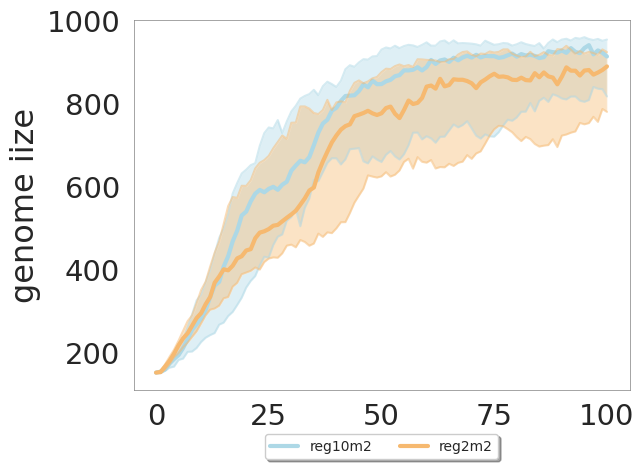

geno_size : 913.64 889.675 0.12597019317097233


<Figure size 640x480 with 0 Axes>

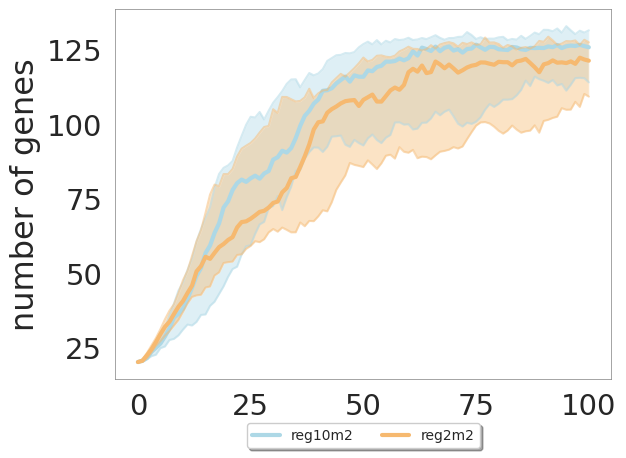

n_genes : 125.78 121.285 0.24882780948800975


<Figure size 640x480 with 0 Axes>

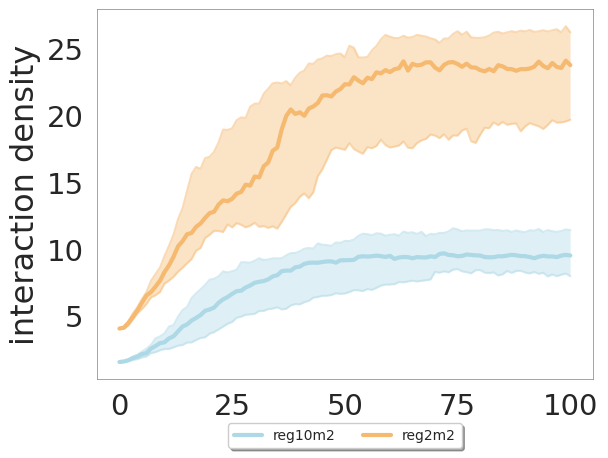

interactions_density : 9.511228235576208 23.73069998923436 1.173735436185757e-09


<Figure size 640x480 with 0 Axes>

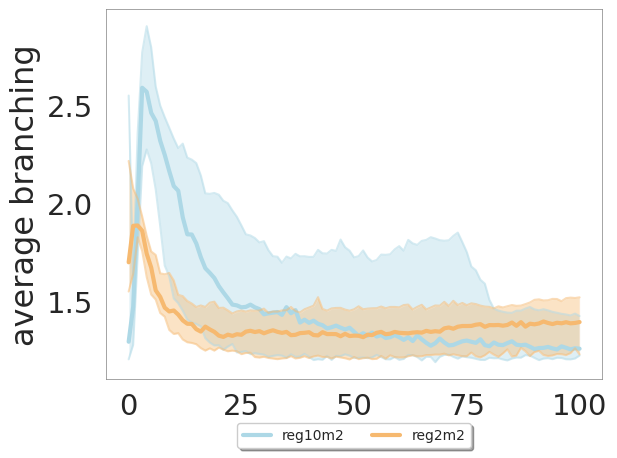

complexity_branch : 1.260595779220778 1.396315175021057 0.49638573117266804


<Figure size 640x480 with 0 Axes>

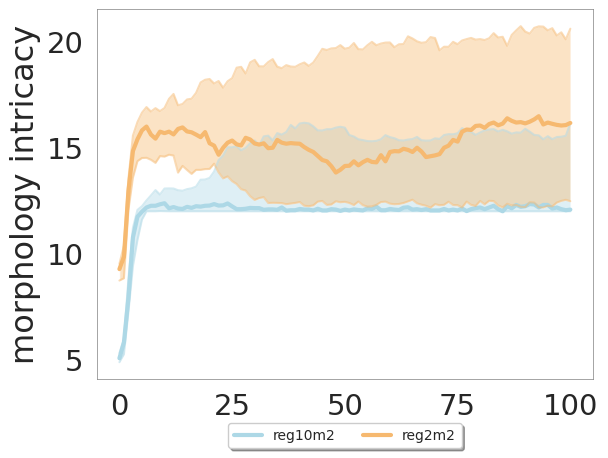

complexity_env : 12.08 16.17 0.025133128401547616


<Figure size 640x480 with 0 Axes>

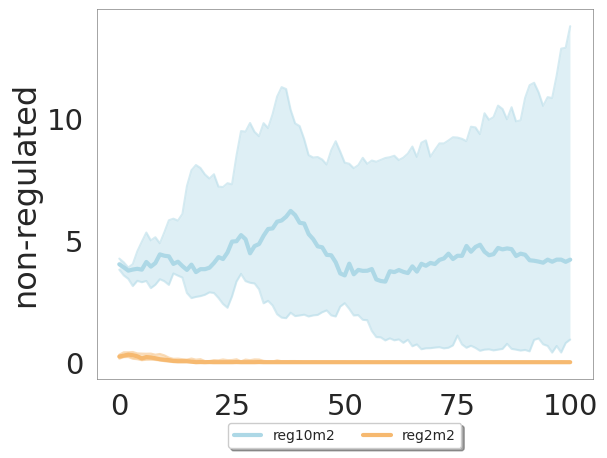

zero_regulators : 4.2 0.0 3.002931123429333e-09


<Figure size 640x480 with 0 Axes>

In [530]:

### COMPLEXITY AND GENO SIZE PROGRESSION

grouped = df_complexity_all.groupby(['experiment_name', 'run', 'gen'])
df_complexity_inner = grouped.agg({
    'geno_size': 'mean',
    'complexity_branch': 'mean',
    'complexity_env': 'mean',
    'n_genes': 'mean',
    'interactions_density': 'mean',
    'zero_regulators': 'mean'
})
df_complexity_inner = df_complexity_inner.reset_index()

q1 = lambda x: x.quantile(0.25)
q3 = lambda x: x.quantile(0.75)

grouped = df_complexity_inner.groupby(['experiment_name', 'gen'])
df_complexity_outer = grouped.agg({
    'geno_size': ['median', q1, q3],
    'complexity_branch': ['median', q1, q3],
    'complexity_env': ['median', q1, q3],
    'n_genes': ['median', q1, q3],
    'interactions_density': ['median', q1, q3],
    'zero_regulators': ['median', q1, q3]
})
df_complexity_outer.columns = [
    ('geno_size', 'median'), ('geno_size', 'Q1'), ('geno_size', 'Q3'),
    ('complexity_branch', 'median'), ('complexity_branch', 'Q1'), ('complexity_branch', 'Q3'),
    ('complexity_env', 'median'), ('complexity_env', 'Q1'), ('complexity_env', 'Q3'),
    ('n_genes', 'median'), ('n_genes', 'Q1'), ('n_genes', 'Q3'),
    ('interactions_density', 'median'), ('interactions_density', 'Q1'), ('interactions_density', 'Q3'),
    ('zero_regulators', 'median'), ('zero_regulators', 'Q1'), ('zero_regulators', 'Q3')
]
df_complexity_outer.columns = ['_'.join(col) for col in df_complexity_outer.columns]
df_complexity_outer = df_complexity_outer.reset_index()

clrs = ['#ADD8E6',
        '#F6B970']
traits_labels = ['genome iize', 'number of genes', 'interaction density', 'average branching', 'morphology intricacy', 'non-regulated']

metrics = ['geno_size', 'n_genes', 'interactions_density', 'complexity_branch', 'complexity_env','zero_regulators']
for idm, metric in enumerate(metrics):

    font = {'font.size': 20}
    plt.rcParams.update(font)
    fig, ax = plt.subplots()#figsize=(3,2))

    plt.xlabel('')
    plt.ylabel(f'{traits_labels[idm]}')
    ax.grid(False)
    ax.spines['top'].set_color('grey')
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_color('grey')
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['bottom'].set_color('grey')
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_color('grey')
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=True)


    for idx_experiment, exp in enumerate(experiments):
        metric_exp = df_complexity_outer[df_complexity_outer['experiment_name'] == exp]
        
        ax.plot(metric_exp['gen'], metric_exp[f'{metric}_median'],
                    label=f'{exp}', c=clrs[idx_experiment], linewidth=3)
        
        ax.fill_between(metric_exp['gen'],
                        metric_exp[f'{metric}_Q1'],
                        metric_exp[f'{metric}_Q3'],
                        alpha=0.4, facecolor=clrs[idx_experiment])
        
        ax.plot(metric_exp['gen'],
        metric_exp[f'{metric}_Q1'],
        linestyle='-', color=clrs[idx_experiment], alpha=0.5, linewidth=1.5)  # Contour line for Q1

        ax.plot(metric_exp['gen'],
        metric_exp[f'{metric}_Q3'],
        linestyle='-', color=clrs[idx_experiment], alpha=0.5, linewidth=1.5)  # Contour line for Q3

        
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),  fancybox=True, shadow=True, ncol=5, fontsize=10)

    plt.show()
    plt.clf()
    fig.savefig(f'{path}/knockouts/{metric}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

    group1_data = df_complexity_inner[(df_complexity_inner['experiment_name'] == 'reg10m2') & (df_complexity_inner['gen'] == 100) ][f'{metric}']
    group2_data = df_complexity_inner[(df_complexity_inner['experiment_name'] == 'reg2m2') & (df_complexity_inner['gen'] == 100) ][f'{metric}']
    _, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
    print(metric, ':', group1_data.median(), group2_data.median(), p_value)




 >>>>> disp_y

 >>> n_genes

 -- reg10m2
Average of 'b' in the first : 1.2517921540305315
Average of 'b' in the second : 1.8696160504827266
  p-value: 0.0062


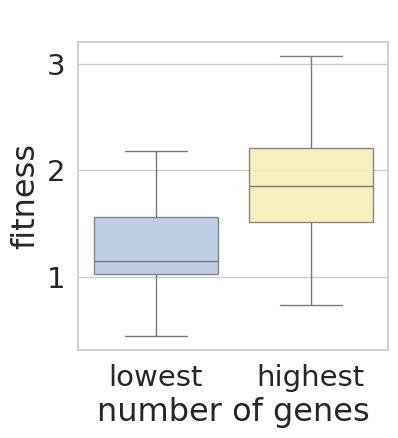


 -- reg2m2
Average of 'b' in the first : 2.1201436329943424
Average of 'b' in the second : 2.162267770400892
  p-value: 0.4306


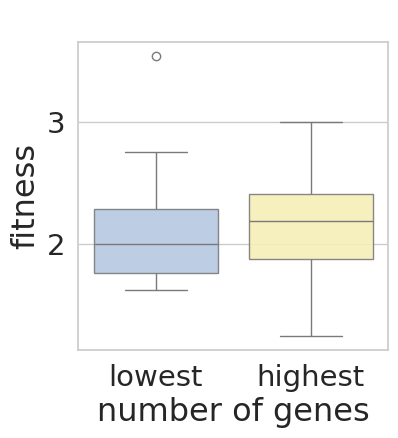

In [531]:

### FIT VS GENOSIZE 


metrics_dist = ['disp_y']
metrics_order = ['n_genes']

for metric_dist in metrics_dist:
    print('\n >>>>>',metric_dist)
    for metric_order in metrics_order:
        print('\n >>>',metric_order)
        for exp in experiments:
            print('\n --',exp)
            df_comp_g = corr_df_all[ (corr_df_all['experiment_name'] == exp) ] 
            df_comp_g = df_comp_g[ (df_comp_g['ranking'] == 'best') ] 
            df_sorted = df_comp_g.sort_values(by=metric_order).reset_index(drop=True)
    
            midpoint = len(df_sorted) // 2
            first_half = df_sorted.iloc[:midpoint]
            second_half = df_sorted.iloc[midpoint:]
            
            # Calculate and display the averages for 'b' in each half
            avg_first_half = first_half[metric_dist].mean()
            avg_second_half = second_half[metric_dist].mean()
    
            print(f"Average of 'b' in the first : {avg_first_half}")
            print(f"Average of 'b' in the second : {avg_second_half}")

            _, p_value = mannwhitneyu(first_half[metric_dist], second_half[metric_dist], alternative='two-sided')
            print(f"  p-value: {round(p_value, 4)}")
            
            # Add a new column to each half to indicate "First Half" or "Second Half"
            first_half['half'] = 'lowest'
            second_half['half'] = 'highest'
            
            #  Concatenate the two halves back into a single DataFrame
            df_concat = pd.concat([first_half, second_half], ignore_index=True)
            
            # Plot variable 'disp_y' for each half using box plots
            plt.figure(figsize=(4, 4))
            bp = sb.boxplot(x='half', y=metric_dist, data=df_concat,palette=["#aec7e8", "#fff7ae"], boxprops=dict(alpha=0.9) )

            plt.xlabel("number of genes")
            plt.ylabel("fitness")
            plt.title(' ')
            plt.savefig(f'{path}/knockouts/geno_fit_{exp}.png', dpi=300, bbox_inches='tight')
            plt.show() 


